In [1]:
import os
import sys
import time
from dataclasses import dataclass
from typing import Dict, List, Optional

import flax
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optax
import pandas as pd
from flax import linen as nn
from tqdm import tqdm

repo_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if repo_root not in sys.path:
    sys.path.append(repo_root)

from optimisers.jax_fixed import (
    custom_sgd,
    custom_sgd_log,
    custom_sgd_rms,
)
from optimisers.jax_learnable_diag import (
    custom_sgd_learnable_diag,
    custom_sgd_log_learnable_diag,
)
from optimisers.jax_learnable_scalar import (
    custom_sgd_learnable_scalar,
    custom_sgd_log_learnable_scalar,
)

# Set JAX to use 64-bit precision
jax.config.update("jax_enable_x64", True)

import optuna
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.ERROR)

/Users/noah-everett/Documents/Research/Induced-Metric-Optimiser/.conda/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Setup

In [19]:
# Configuration
tolerance = 1e-10
time_steps = 1000

# Configuration: Set to True for full experiment, False for demo
RUN_FULL_EXPERIMENT = False

# Test Functions

In [3]:
# Himmelblau function
@jax.jit
def himmelblau_function(params):
    x, y = params
    return (x**2 + y - 11)**2 + (x + y**2 - 7)**2

# Ackley function
@jax.jit
def ackley_function(params):
    x, y = params
    a, b, c = 20.0, 0.2, 2 * jnp.pi
    term1 = -a * jnp.exp(-b * jnp.sqrt(0.5 * (x**2 + y**2)))
    term2 = -jnp.exp(0.5 * (jnp.cos(c * x) + jnp.cos(c * y)))
    return term1 + term2 + a + jnp.e

# Rastrigin function
@jax.jit
def rastrigin_function(params):
    x, y = params
    A = 10.0
    return A * 2 + (x**2 - A * jnp.cos(2 * jnp.pi * x)) + (y**2 - A * jnp.cos(2 * jnp.pi * y))

# Define the Beale function
@jax.jit
def beale_function(params):
    x, y = params
    term1 = (1.5 - x + x * y)**2
    term2 = (2.25 - x + x * y**2)**2
    term3 = (2.625 - x + x * y**3)**2
    return term1 + term2 + term3


# Define the Rosenbrock function with a=1, b=100
@jax.jit
def rosenbrock_function(params):
    x, y = params
    a = 1.0
    b = 100.0
    return (a - x)**2 + b * (y - x**2)**2

# Gradients
himmelblau_gradient = jax.jit(jax.grad(himmelblau_function))
ackley_gradient = jax.jit(jax.grad(ackley_function))
rastrigin_gradient = jax.jit(jax.grad(rastrigin_function))
beale_gradient = jax.jit(jax.grad(beale_function))
rosenbrock_gradient = jax.jit(jax.grad(rosenbrock_function))

# Test function registry
test_functions = {
    'beale': {
        'func': beale_function,
        'grad': beale_gradient,
        'global_min': jnp.array([3.0, 0.5]),
        'initial': jnp.array([0.0, 0.0]),
        'xlim': (-1, 4),
        'ylim': (-1, 1),
        'tolerance': 1e-7
    },
    'rosenbrock': {
        'func': rosenbrock_function,
        'grad': rosenbrock_gradient,
        'global_min': jnp.array([1.0, 1.0]),
        'initial': jnp.array([0.0, 0.0]),
        'xlim': (-0.5, 1.5),
        'ylim': (-0.5, 2.0),
        'tolerance': 1e-7
    },
    'himmelblau': {
        'func': himmelblau_function,
        'grad': himmelblau_gradient,
        'global_min': jnp.array([3.0, 2.0]),  # One of four global minima
        'initial': jnp.array([0.0, 0.0]),
        'xlim': (-5, 5),
        'ylim': (-5, 5),
        'tolerance': 1e-6
    },
    'ackley': {
        'func': ackley_function,
        'grad': ackley_gradient,
        'global_min': jnp.array([0.0, 0.0]),
        'initial': jnp.array([2.0, 2.0]),
        'xlim': (-5, 5),
        'ylim': (-5, 5),
        'tolerance': 1e-6
    },
    'rastrigin': {
        'func': rastrigin_function,
        'grad': rastrigin_gradient,
        'global_min': jnp.array([0.0, 0.0]),
        'initial': jnp.array([2.0, 2.0]),
        'xlim': (-5, 5),
        'ylim': (-5, 5),
        'tolerance': 1e-6
    }
}

print("Added test functions:")
for name, info in test_functions.items():
    print(f"  {name}: global minimum = {info['global_min']}")

Added test functions:
  beale: global minimum = [3.  0.5]
  rosenbrock: global minimum = [1. 1.]
  himmelblau: global minimum = [3. 2.]
  ackley: global minimum = [0. 0.]
  rastrigin: global minimum = [0. 0.]


# Optimisation Framework

In [4]:
@dataclass
class OptimisationResult:
    """Store results from optimisation run"""
    optimiser_name: str
    function_name: str
    converged: bool
    iterations: int
    final_value: float
    final_params: jnp.ndarray
    path: jnp.ndarray
    convergence_history: List[float]
    runtime_seconds: float
    config: Dict

def run_optimiser_on_function(optimiser_name: str, optimiser, 
                             function_info: Dict, config: Dict = None, 
                             max_iterations: int = 1000) -> OptimisationResult:
    """Run a single optimiser on a single function with timing and convergence tracking"""
    
    func = function_info['func']
    grad_func = function_info['grad']
    initial_params = function_info['initial']
    tolerance = function_info['tolerance']
    
    if config is None:
        config = {}
    
    # Initialise
    opt_state = optimiser.init(initial_params)
    params = initial_params.copy()
    path = [params.copy()]
    convergence_history = [float(func(params))]
    
    converged = False
    iterations = 0
    runtime = 0.0
    
    for i in range(max_iterations):
        # Start timing after first iteration to exclude JIT compilation
        if i > 0:
            start_time = time.time()
        
        # Compute gradients
        grads = grad_func(params)
        
        # Update parameters - handle different optimizer signatures
        if optimiser_name in {'custom_sgd_log', 'custom_sgd_log_learnable_diag', 'custom_sgd_log_learnable_scalar'}:
            # Log variants expect loss as an additional argument
            current_loss = func(params)
            updates, opt_state = optimiser.update(grads, opt_state, current_loss, params)
        else:
            # All other optimizers follow standard optax signature
            updates, opt_state = optimiser.update(grads, opt_state, params)
        
        params = optax.apply_updates(params, updates)
        
        # End timing after first iteration
        if i > 0:
            runtime += time.time() - start_time

        path.append(params.copy())
        
        # Check convergence
        current_value = func(params)
        convergence_history.append(float(current_value))
        
        if current_value <= tolerance:
            converged = True
            iterations = i + 1
            break
    
    #estimate first iteration without JIT time
    runtime += runtime + runtime/iterations if iterations > 0 else 0.0
    
    if not converged:
        iterations = max_iterations
    
    return OptimisationResult(
        optimiser_name=optimiser_name,
        function_name=function_info.get('name', 'unknown'),
        converged=converged,
        iterations=iterations,
        final_value=float(func(params)),
        final_params=params,
        path=jnp.array(path),
        convergence_history=convergence_history,
        runtime_seconds=runtime,  # Now excludes first iteration JIT time
        config=config
    )


# Optuna Hyperparameter Optimization

In [20]:
# Optuna Configuration
N_TRIALS = 100 if RUN_FULL_EXPERIMENT else 20  # Number of trials per optimizer-function combination
N_STARTUP_TRIALS = 10  # Random sampling before TPE
TIMEOUT = None  # No timeout, run all trials
USE_PRUNING = True  # Enable ASHA-like pruning

print("OPTUNA HYPERPARAMETER SEARCH CONFIGURATION")
print("=" * 50)
print(f"Mode: {'FULL SEARCH' if RUN_FULL_EXPERIMENT else 'DEMO SEARCH'}")
print(f"Trials per optimizer-function: {N_TRIALS}")
print(f"Total trials: {N_TRIALS * len(test_functions) * 10}")  # 10 optimizers
print(f"Pruning enabled: {USE_PRUNING}")
print(f"Estimated runtime: ~{N_TRIALS * len(test_functions) * 10 * 0.3 / 60:.1f} minutes")
print("=" * 50)

OPTUNA HYPERPARAMETER SEARCH CONFIGURATION
Mode: DEMO SEARCH
Trials per optimizer-function: 20
Total trials: 1000
Pruning enabled: True
Estimated runtime: ~5.0 minutes


In [6]:
def create_optimizer_objective(optimizer_name: str, function_info: Dict):
    """Create Optuna objective function for a specific optimizer and test function"""
    
    def objective(trial: optuna.Trial) -> float:
        """Optuna objective function - returns metric to minimize"""
        
        # Suggest hyperparameters based on optimizer type
        if optimizer_name == 'adam':
            config = {
                'learning_rate': trial.suggest_float('learning_rate', 1e-6, 10.0, log=True),
                'b1': trial.suggest_float('b1', 0.0, 0.99),
                'b2': trial.suggest_float('b2', 0.8, 0.999),
                'eps': trial.suggest_float('eps', 1e-10, 1e-6, log=True)
            }
            optimizer = optax.adam(**config)
            
        elif optimizer_name == 'sgd':
            config = {
                'learning_rate': trial.suggest_float('learning_rate', 1e-6, 10.0, log=True),
                'momentum': trial.suggest_float('momentum', 0.0, 0.99)
            }
            optimizer = optax.sgd(**config)
            
        elif optimizer_name == 'custom_sgd':
            config = {
                'learning_rate': trial.suggest_float('learning_rate', 1e-6, 10.0, log=True),
                'momentum': trial.suggest_float('momentum', 0.0, 0.99),
                'xi': trial.suggest_float('xi', 0.01, 10.0, log=True),
                'beta': 0.0  # Fixed
            }
            optimizer = custom_sgd(**config)
            
        elif optimizer_name == 'custom_sgd_log':
            config = {
                'learning_rate': trial.suggest_float('learning_rate', 1e-6, 10.0, log=True),
                'momentum': trial.suggest_float('momentum', 0.0, 0.99),
                'xi': trial.suggest_float('xi', 0.01, 10.0, log=True),
                'beta': 0.0  # Fixed
            }
            optimizer = custom_sgd_log(**config)
            
        elif optimizer_name == 'custom_sgd_rms':
            config = {
                'learning_rate': trial.suggest_float('learning_rate', 1e-6, 10.0, log=True),
                'momentum': trial.suggest_float('momentum', 0.0, 0.99),
                'xi': trial.suggest_float('xi', 0.01, 10.0, log=True),
                'beta': 0.0,  # Fixed
                'beta_rms': trial.suggest_float('beta_rms', 0.8, 0.999),
                'eps': trial.suggest_float('eps', 1e-10, 1e-6, log=True)
            }
            optimizer = custom_sgd_rms(**config)
            
        elif optimizer_name == 'muon':
            config = {
                'learning_rate': trial.suggest_float('learning_rate', 1e-6, 10.0, log=True),
                'adam_b1': trial.suggest_float('adam_b1', 0.0, 0.99),
                'adam_b2': trial.suggest_float('adam_b2', 0.8, 0.999),
                'eps': trial.suggest_float('eps', 1e-10, 1e-6, log=True),
                'beta': trial.suggest_float('beta', 0.9, 0.99)
            }
            optimizer = optax.contrib.muon(**config)
            
        elif optimizer_name == 'custom_sgd_learnable_diag':
            config = {
                'learning_rate': trial.suggest_float('learning_rate', 1e-6, 10.0, log=True),
                'momentum': trial.suggest_float('momentum', 0.0, 0.99),
                'xi': trial.suggest_float('xi', 0.01, 10.0, log=True),
                'beta': trial.suggest_float('beta', 0.75, 0.99),
                'metric_lr': trial.suggest_float('metric_lr', 1e-5, 1.0, log=True),
                'metric_reg': trial.suggest_float('metric_reg', 1e-6, 1e-3, log=True),
                'metric_clip': trial.suggest_float('metric_clip', 1.0, 5.0)
            }
            optimizer = custom_sgd_learnable_diag(**config)
            
        elif optimizer_name == 'custom_sgd_log_learnable_diag':
            config = {
                'learning_rate': trial.suggest_float('learning_rate', 1e-6, 10.0, log=True),
                'momentum': trial.suggest_float('momentum', 0.0, 0.99),
                'xi': trial.suggest_float('xi', 0.01, 10.0, log=True),
                'beta': trial.suggest_float('beta', 0.75, 0.99),
                'metric_lr': trial.suggest_float('metric_lr', 1e-5, 1.0, log=True),
                'metric_reg': trial.suggest_float('metric_reg', 1e-6, 1e-3, log=True),
                'metric_clip': trial.suggest_float('metric_clip', 1.0, 5.0)
            }
            optimizer = custom_sgd_log_learnable_diag(**config)
            
        elif optimizer_name == 'custom_sgd_learnable_scalar':
            config = {
                'learning_rate': trial.suggest_float('learning_rate', 1e-6, 10.0, log=True),
                'momentum': trial.suggest_float('momentum', 0.0, 0.99),
                'xi': trial.suggest_float('xi', 0.01, 10.0, log=True),
                'beta': trial.suggest_float('beta', 0.75, 0.99),
                'metric_lr': trial.suggest_float('metric_lr', 1e-5, 1.0, log=True),
                'metric_reg': trial.suggest_float('metric_reg', 1e-6, 1e-3, log=True),
                'metric_clip': trial.suggest_float('metric_clip', 1.0, 5.0)
            }
            optimizer = custom_sgd_learnable_scalar(**config)
            
        elif optimizer_name == 'custom_sgd_log_learnable_scalar':
            config = {
                'learning_rate': trial.suggest_float('learning_rate', 1e-6, 10.0, log=True),
                'momentum': trial.suggest_float('momentum', 0.0, 0.99),
                'xi': trial.suggest_float('xi', 0.01, 10.0, log=True),
                'beta': trial.suggest_float('beta', 0.75, 0.99),
                'metric_lr': trial.suggest_float('metric_lr', 1e-5, 1.0, log=True),
                'metric_reg': trial.suggest_float('metric_reg', 1e-6, 1e-3, log=True),
                'metric_clip': trial.suggest_float('metric_clip', 1.0, 5.0)
            }
            optimizer = custom_sgd_log_learnable_scalar(**config)
        else:
            raise ValueError(f"Unknown optimizer: {optimizer_name}")
        
        # Run optimization
        try:
            result = run_optimiser_on_function(
                optimizer_name, optimizer, function_info, 
                config=config, max_iterations=1000
            )
            
            # Report intermediate values for pruning (every 100 iterations)
            if USE_PRUNING:
                for step in range(0, len(result.convergence_history), 100):
                    trial.report(result.convergence_history[step], step)
                    if trial.should_prune():
                        raise optuna.TrialPruned()
            
            # Primary objective: minimize iterations if converged, else minimize final value
            if result.converged:
                # For converged runs, minimize iterations (with small penalty for runtime)
                return result.iterations + 0.01 * result.runtime_seconds
            else:
                # For non-converged runs, minimize final value (heavily penalized)
                return 1000 + result.final_value
                
        except Exception as e:
            # print(f"Trial failed with error: {e}")
            return float('inf')
    
    return objective

In [7]:
def run_optuna_optimization():
    """Run Optuna hyperparameter optimization for all optimizer-function combinations"""
    
    optimizer_names = [
        'adam', 'sgd', 'custom_sgd', 'custom_sgd_log', 'custom_sgd_rms', 'muon',
        'custom_sgd_learnable_diag', 'custom_sgd_log_learnable_diag',
        'custom_sgd_learnable_scalar', 'custom_sgd_log_learnable_scalar'
    ]
    
    all_studies = {}
    all_best_results = []
    
    total_combinations = len(optimizer_names) * len(test_functions)
    
    print(f"\nRunning Optuna optimization for {total_combinations} optimizer-function combinations...")
    print(f"Total trials: {total_combinations * N_TRIALS}\n")
    
    with tqdm(total=total_combinations, desc="Optuna optimization") as pbar:
        for func_name, func_info in test_functions.items():
            func_info_with_name = {**func_info, 'name': func_name}
            
            for optimizer_name in optimizer_names:
                study_name = f"{optimizer_name}_{func_name}"
                
                # Create study with TPE sampler and optional pruner
                if USE_PRUNING:
                    pruner = MedianPruner(
                        n_startup_trials=N_STARTUP_TRIALS,
                        n_warmup_steps=100,  # Wait 100 steps before pruning
                        interval_steps=100   # Check every 100 steps
                    )
                else:
                    pruner = optuna.pruners.NopPruner()
                
                sampler = TPESampler(n_startup_trials=N_STARTUP_TRIALS, seed=42)
                
                study = optuna.create_study(
                    study_name=study_name,
                    direction='minimize',
                    sampler=sampler,
                    pruner=pruner
                )
                
                # Create objective function
                objective = create_optimizer_objective(optimizer_name, func_info_with_name)
                
                # Optimize
                try:
                    study.optimize(
                        objective,
                        n_trials=N_TRIALS,
                        timeout=TIMEOUT,
                        show_progress_bar=True,
                        catch=(Exception,)
                    )
                    
                    # Store study
                    all_studies[study_name] = study
                    
                    # Get best trial
                    if len(study.trials) > 0 and study.best_trial is not None:
                        best_trial = study.best_trial
                        
                        # Re-run with best params to get full result
                        best_config = best_trial.params
                        
                        # Create optimizer with best params
                        if optimizer_name == 'adam':
                            optimizer = optax.adam(**best_config)
                        elif optimizer_name == 'sgd':
                            optimizer = optax.sgd(**best_config)
                        elif optimizer_name == 'custom_sgd':
                            optimizer = custom_sgd(**best_config)
                        elif optimizer_name == 'custom_sgd_log':
                            optimizer = custom_sgd_log(**best_config)
                        elif optimizer_name == 'custom_sgd_rms':
                            optimizer = custom_sgd_rms(**best_config)
                        elif optimizer_name == 'muon':
                            optimizer = optax.contrib.muon(**best_config)
                        elif optimizer_name == 'custom_sgd_learnable_diag':
                            optimizer = custom_sgd_learnable_diag(**best_config)
                        elif optimizer_name == 'custom_sgd_log_learnable_diag':
                            optimizer = custom_sgd_log_learnable_diag(**best_config)
                        elif optimizer_name == 'custom_sgd_learnable_scalar':
                            optimizer = custom_sgd_learnable_scalar(**best_config)
                        elif optimizer_name == 'custom_sgd_log_learnable_scalar':
                            optimizer = custom_sgd_log_learnable_scalar(**best_config)
                        
                        result = run_optimiser_on_function(
                            optimizer_name, optimizer, func_info_with_name,
                            config=best_config, max_iterations=1000
                        )
                        
                        all_best_results.append(result)
                        
                except Exception as e:
                    print(f"\nError optimizing {study_name}: {e}")
                
                pbar.update(1)
    
    return all_studies, all_best_results

# Run Optuna optimization
optuna_studies, optuna_results = run_optuna_optimization()

print(f"\n✅ Optuna optimization completed!")
print(f"Total studies: {len(optuna_studies)}")
print(f"Total best results: {len(optuna_results)}")
print(f"Successful convergences: {sum(1 for r in optuna_results if r.converged)}")
print(f"Failed convergences: {sum(1 for r in optuna_results if not r.converged)}")


Running Optuna optimization for 50 optimizer-function combinations...
Total trials: 5000



Best trial: 92. Best value: 60.0004: 100%|██████████| 100/100 [00:29<00:00,  3.39it/s]
                                                                   
                                                                                
Optuna optimization:   2%|▏         | 1/50 [00:29<24:07, 29.54s/it]             

[W 2025-11-21 08:28:18,664] Trial 1 failed with parameters: {'learning_rate': 0.1330324510152292, 'momentum': 0.5926718993550663} because of the following error: The value nan is not acceptable.
[W 2025-11-21 08:28:18,667] Trial 1 failed with value nan.


                                                                   
                                                                               
Optuna optimization:   2%|▏         | 1/50 [00:30<24:07, 29.54s/it]            

[W 2025-11-21 08:28:19,338] Trial 6 failed with parameters: {'learning_rate': 0.6715811311069948, 'momentum': 0.2102157195714934} because of the following error: The value nan is not acceptable.
[W 2025-11-21 08:28:19,341] Trial 6 failed with value nan.


...

[W 2025-11-21 08:35:41,429] Trial 1 failed with parameters: {'learning_rate': 0.1330324510152292, 'momentum': 0.5926718993550663} because of the following error: The value nan is not acceptable.
[W 2025-11-21 08:35:41,431] Trial 1 failed with value nan.


                                                                    
                                                                                   
Optuna optimization:  42%|████▏     | 21/50 [07:53<09:32, 19.75s/it]               

[W 2025-11-21 08:35:42,055] Trial 6 failed with parameters: {'learning_rate': 0.6715811311069948, 'momentum': 0.2102157195714934} because of the following error: The value nan is not acceptable.
[W 2025-11-21 08:35:42,057] Trial 6 failed with value nan.


Optuna optimization: 100%|██████████| 50/50 [18:24<00:00, 22.10s/it]


✅ Optuna optimization completed!
Total studies: 50
Total best results: 50
Successful convergences: 35
Failed convergences: 15


# Optuna Results Analysis

In [10]:
# Analyze Optuna results
optuna_df = analyse_results(optuna_results)
optuna_best_df = get_best_results(optuna_df)

print("OPTUNA RESULTS SUMMARY:")
print(f"Total experiments: {len(optuna_df)}")
print(f"Unique optimizer-function combinations: {len(optuna_best_df)}")
print(f"Overall convergence rate: {optuna_df['converged'].mean():.2%}")

print("\nConvergence by optimizer:")
optuna_convergence_by_opt = optuna_df.groupby('optimiser')['converged'].agg(['count', 'sum', 'mean'])
optuna_convergence_by_opt.columns = ['total_runs', 'converged_runs', 'convergence_rate']
print(optuna_convergence_by_opt)

print("\nConvergence by function:")
optuna_convergence_by_func = optuna_df.groupby('function')['converged'].agg(['count', 'sum', 'mean'])
optuna_convergence_by_func.columns = ['total_runs', 'converged_runs', 'convergence_rate']
print(optuna_convergence_by_func)

OPTUNA RESULTS SUMMARY:
Total experiments: 50
Unique optimizer-function combinations: 50
Overall convergence rate: 70.00%

Convergence by optimizer:
                                 total_runs  converged_runs  convergence_rate
optimiser                                                                    
adam                                      5               3               0.6
custom_sgd                                5               3               0.6
custom_sgd_learnable_diag                 5               3               0.6
custom_sgd_learnable_scalar               5               3               0.6
custom_sgd_log                            5               5               1.0
custom_sgd_log_learnable_diag             5               5               1.0
custom_sgd_log_learnable_scalar           5               5               1.0
custom_sgd_rms                            5               3               0.6
muon                                      5               2            

In [11]:
# Display best hyperparameters found by Optuna
print("=" * 80)
print("BEST HYPERPARAMETERS FOUND BY OPTUNA")
print("=" * 80)

for func_name in test_functions.keys():
    print(f"\n{func_name.upper()} FUNCTION:")
    print("-" * 50)
    
    for result in optuna_results:
        if result.function_name == func_name:
            status = "✓" if result.converged else "✗"
            print(f"{status} {result.optimiser_name:30s} | {result.iterations:4d} iter | "
                  f"{result.runtime_seconds*1000:6.1f} ms | {result.final_value:.2e}")
            
            # Display config
            config_str = " | ".join([f"{k}: {v:.4g}" if isinstance(v, float) else f"{k}: {v}" 
                                     for k, v in result.config.items()])
            print(f"  └─ {config_str}")
            print()

print("=" * 80)

BEST HYPERPARAMETERS FOUND BY OPTUNA

BEALE FUNCTION:
--------------------------------------------------
✓ adam                           |   60 iter |   39.0 ms | 7.48e-08
  └─ learning_rate: 1.289 | b1: 0.7007 | b2: 0.9931 | eps: 1.042e-10

✓ sgd                            |   97 iter |   15.0 ms | 9.78e-08
  └─ learning_rate: 0.02996 | momentum: 0.7438

✓ custom_sgd                     |  176 iter |   17.8 ms | 9.53e-08
  └─ learning_rate: 0.1438 | momentum: 0.6663 | xi: 0.438

✓ custom_sgd_log                 |  456 iter |   51.9 ms | 9.93e-08
  └─ learning_rate: 4.316 | momentum: 0.1688 | xi: 2.77

✓ custom_sgd_rms                 |   82 iter |    8.7 ms | 9.27e-08
  └─ learning_rate: 0.4329 | momentum: 0.8066 | xi: 0.01783 | beta_rms: 0.9793 | eps: 4.074e-10

✗ muon                           | 1000 iter |  690.0 ms | 7.62e-05
  └─ learning_rate: 0.009595 | adam_b1: 0.7895 | adam_b2: 0.8549 | eps: 1.904e-09 | beta: 0.9685

✓ custom_sgd_learnable_diag      |   59 iter |    6.0 ms |

TypeError: '<' not supported between instances of 'NoneType' and 'float'

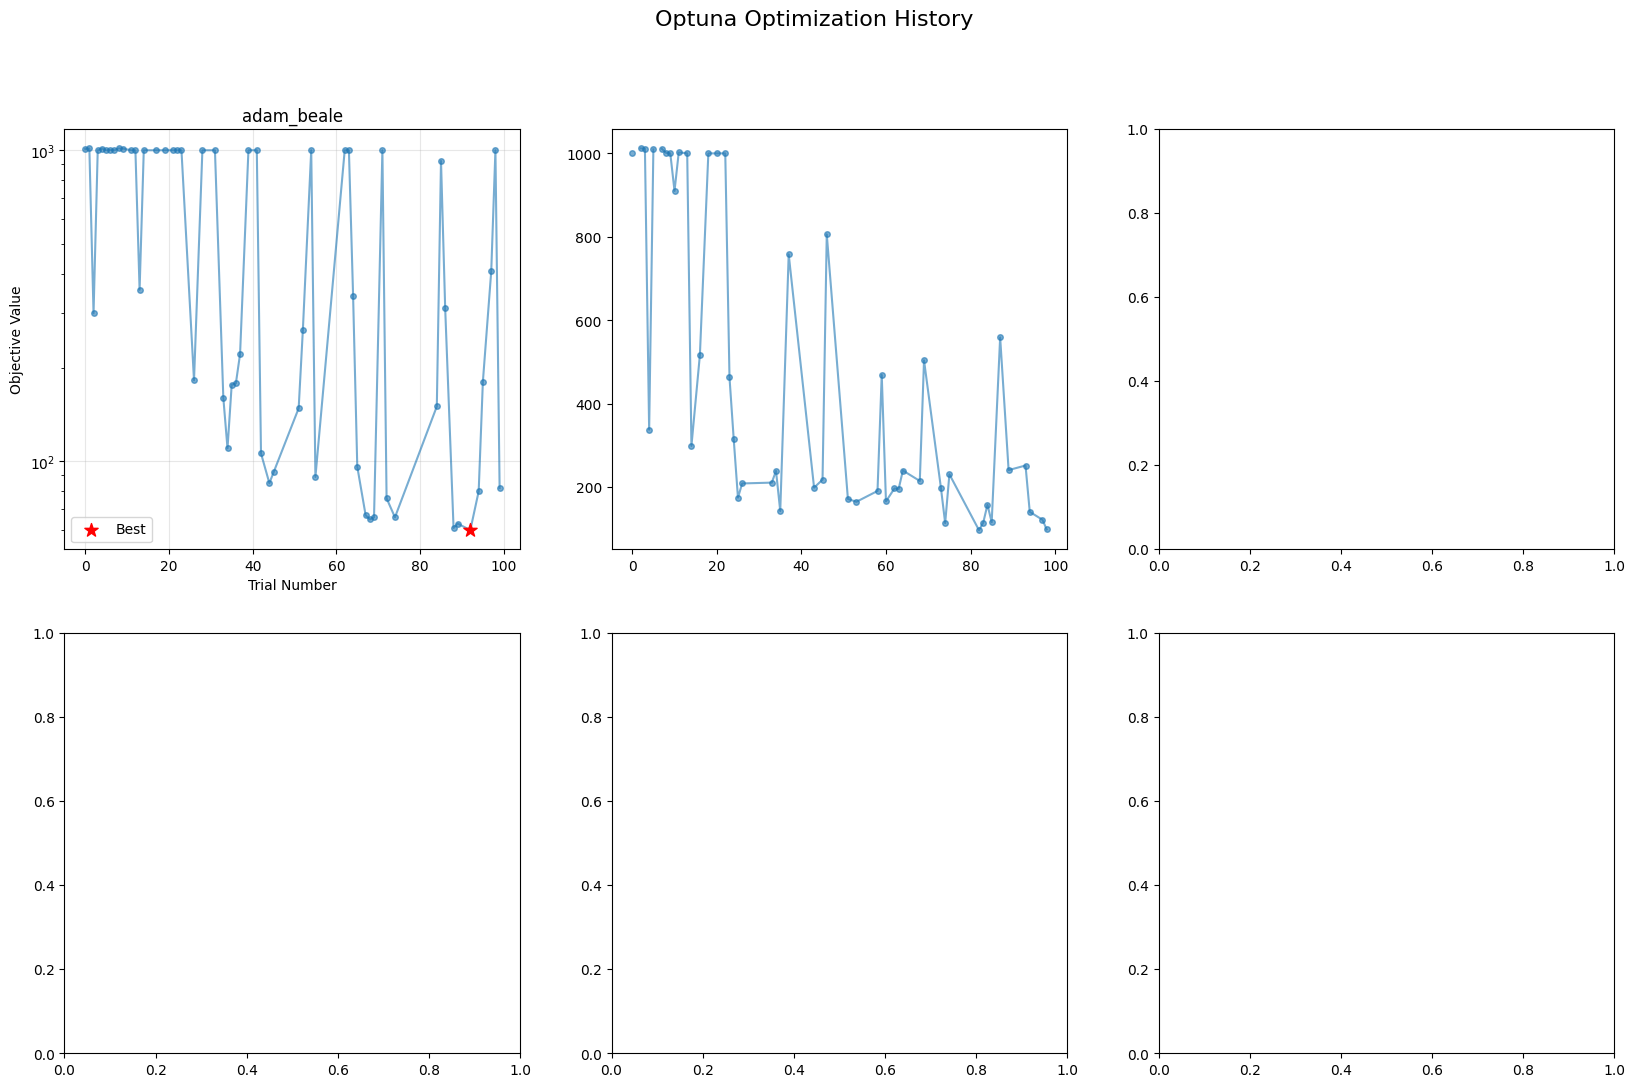

In [12]:
# Visualize Optuna optimization history
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Optuna Optimization History', fontsize=16)

# Select a few representative optimizer-function combinations to visualize
sample_studies = list(optuna_studies.items())[:6]

for idx, (study_name, study) in enumerate(sample_studies):
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]
    
    # Plot optimization history
    trials = study.trials
    values = [t.value for t in trials if t.value != float('inf')]
    trial_numbers = [t.number for t in trials if t.value != float('inf')]
    
    if len(values) > 0:
        ax.plot(trial_numbers, values, 'o-', alpha=0.6, markersize=4)
        
        # Mark best trial
        best_idx = np.argmin(values)
        ax.scatter(trial_numbers[best_idx], values[best_idx], 
                  color='red', s=100, marker='*', zorder=10, label='Best')
        
        ax.set_xlabel('Trial Number')
        ax.set_ylabel('Objective Value')
        ax.set_title(study_name)
        ax.set_yscale('log')
        ax.grid(True, alpha=0.3)
        ax.legend()

plt.tight_layout()
plt.show()

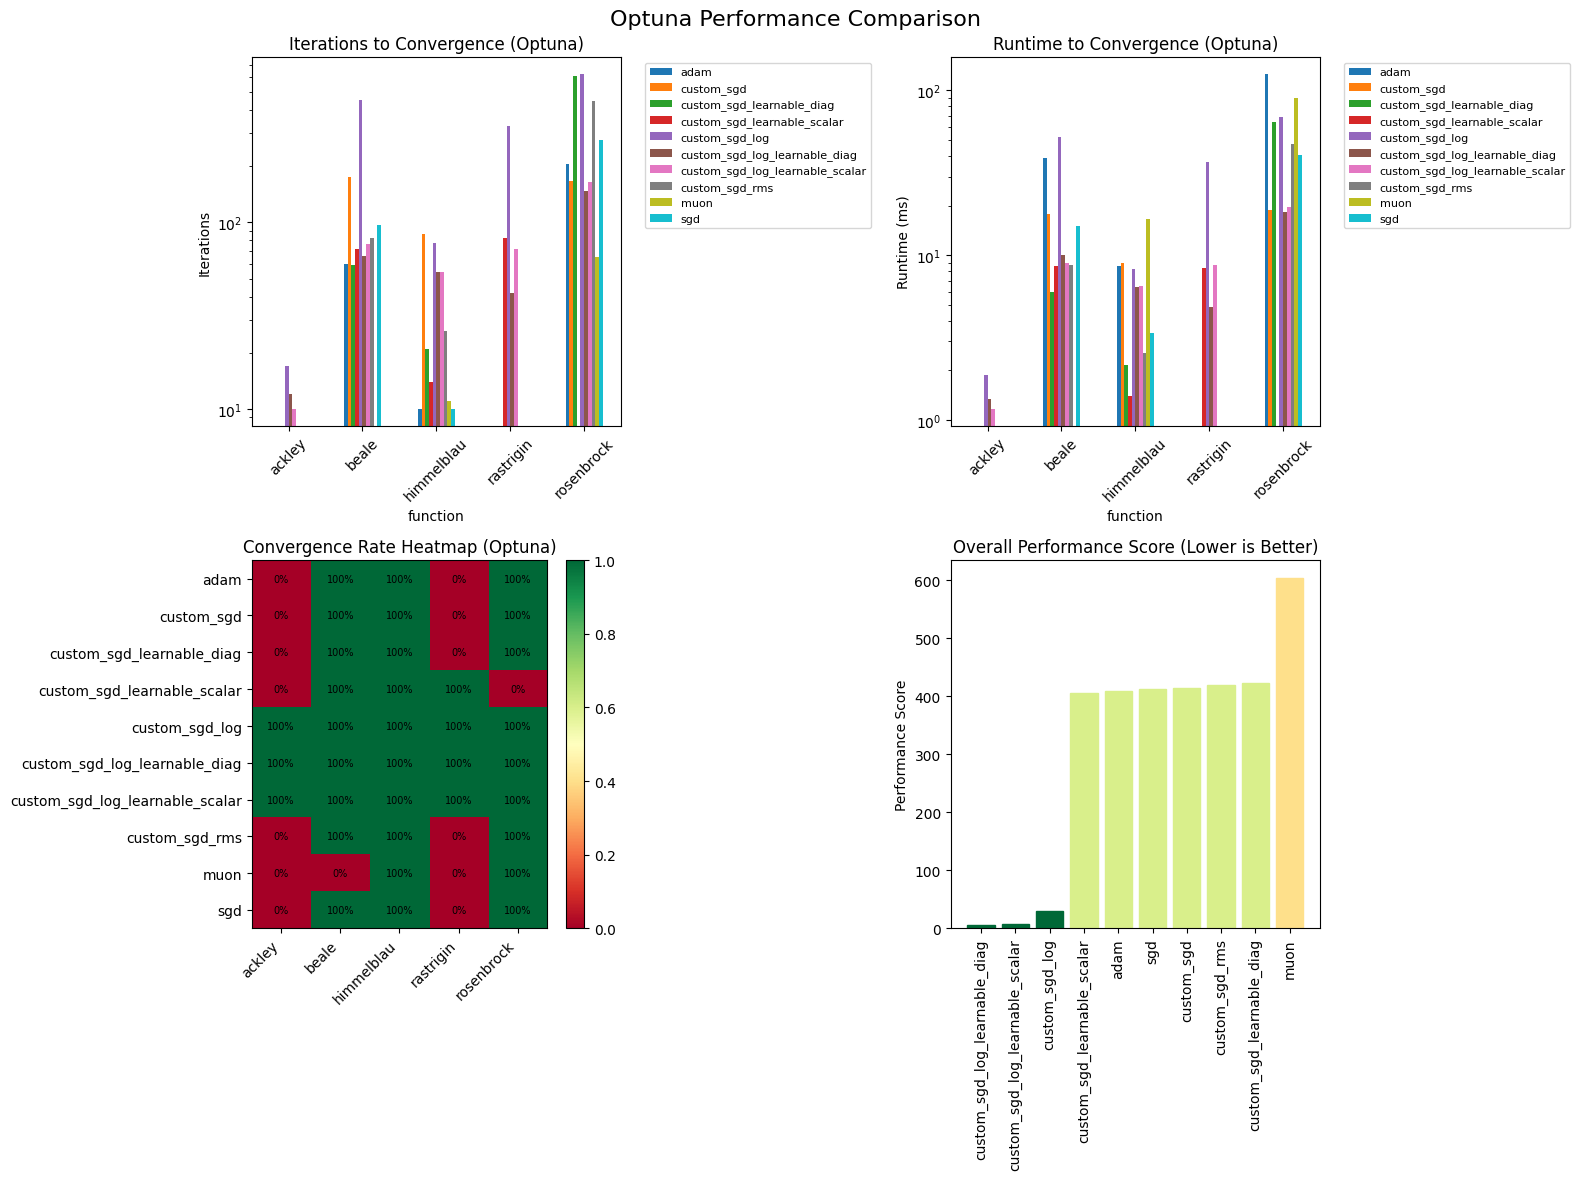

In [13]:
# Performance comparison: Optuna vs Grid Search results
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Optuna Performance Comparison', fontsize=16)

# 1. Iterations to convergence (converged runs only)
ax = axes[0, 0]
optuna_converged_best = optuna_best_df[optuna_best_df['converged'] == True]
if len(optuna_converged_best) > 0:
    pivot_iterations = optuna_converged_best.pivot(index='function', columns='optimiser', values='iterations')
    pivot_iterations.plot(kind='bar', ax=ax, rot=45)
    ax.set_title('Iterations to Convergence (Optuna)')
    ax.set_ylabel('Iterations')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    ax.set_yscale('log')

# 2. Runtime comparison
ax = axes[0, 1]
if len(optuna_converged_best) > 0:
    pivot_runtime = optuna_converged_best.pivot(index='function', columns='optimiser', values='runtime_ms')
    pivot_runtime.plot(kind='bar', ax=ax, rot=45)
    ax.set_title('Runtime to Convergence (Optuna)')
    ax.set_ylabel('Runtime (ms)')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    ax.set_yscale('log')

# 3. Convergence rate heatmap
ax = axes[1, 0]
optuna_convergence_matrix = optuna_df.groupby(['optimiser', 'function'])['converged'].mean().unstack()
im = ax.imshow(optuna_convergence_matrix.values, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
ax.set_xticks(range(len(optuna_convergence_matrix.columns)))
ax.set_xticklabels(optuna_convergence_matrix.columns, rotation=45, ha='right')
ax.set_yticks(range(len(optuna_convergence_matrix.index)))
ax.set_yticklabels(optuna_convergence_matrix.index)
ax.set_title('Convergence Rate Heatmap (Optuna)')
plt.colorbar(im, ax=ax)

# Add text annotations
for i in range(len(optuna_convergence_matrix.index)):
    for j in range(len(optuna_convergence_matrix.columns)):
        text = ax.text(j, i, f'{optuna_convergence_matrix.iloc[i, j]:.0%}',
                      ha="center", va="center", color="black", fontsize=7)

# 4. Overall performance ranking
ax = axes[1, 1]
performance_scores = []
for optimiser in optuna_best_df['optimiser'].unique():
    opt_data = optuna_best_df[optuna_best_df['optimiser'] == optimiser]
    converged_rate = opt_data['converged'].mean()
    avg_iterations = opt_data[opt_data['converged']]['iterations'].mean() if len(opt_data[opt_data['converged']]) > 0 else 1000
    avg_runtime = opt_data[opt_data['converged']]['runtime_ms'].mean() if len(opt_data[opt_data['converged']]) > 0 else 1000
    
    # Performance score combines convergence rate and speed
    score = (1 - converged_rate) * 1000 + avg_iterations * 0.1 + avg_runtime * 0.01
    performance_scores.append({'optimiser': optimiser, 'score': score, 'convergence_rate': converged_rate})

performance_df = pd.DataFrame(performance_scores).sort_values('score')
bars = ax.bar(range(len(performance_df)), performance_df['score'])
ax.set_xticks(range(len(performance_df)))
ax.set_xticklabels(performance_df['optimiser'], rotation=90)
ax.set_title('Overall Performance Score (Lower is Better)')
ax.set_ylabel('Performance Score')

# Color bars by convergence rate
colors = plt.cm.RdYlGn(performance_df['convergence_rate'])
for bar, color in zip(bars, colors):
    bar.set_color(color)

plt.tight_layout()
plt.show()

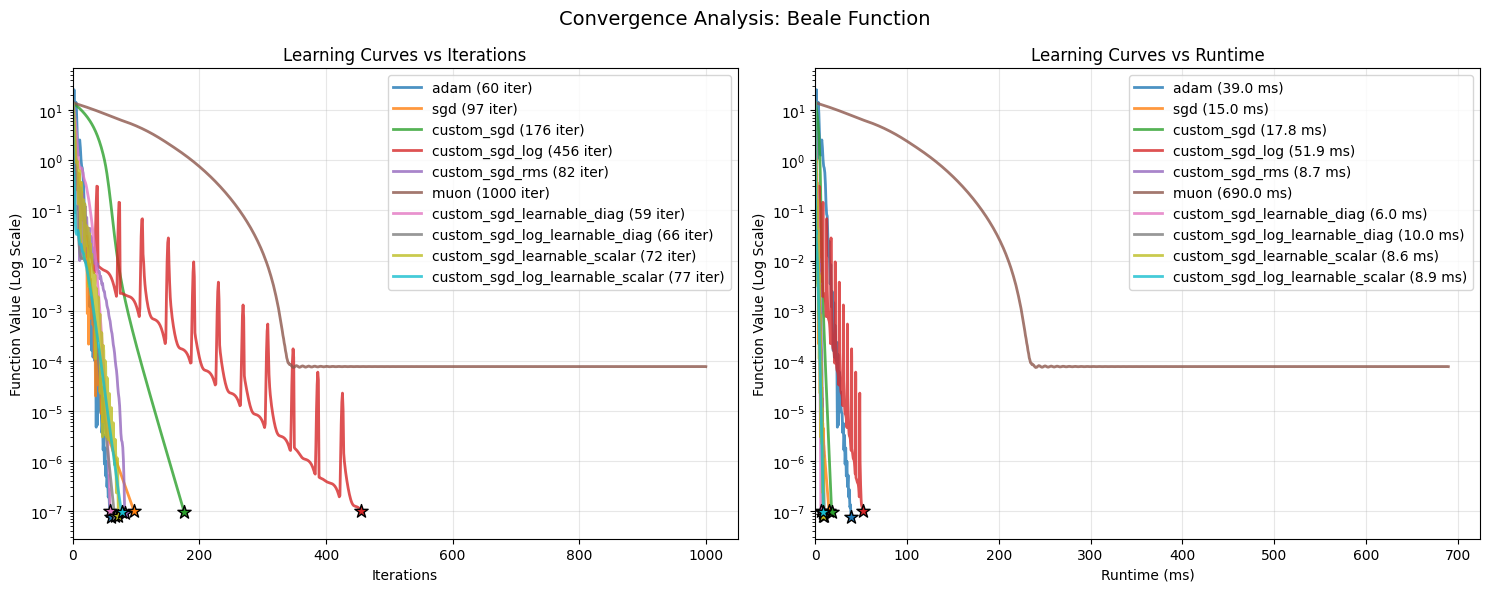


Beale Function Summary:
--------------------------------------------------
adam                           : ✓ Converged  |   60 iter |   39.0 ms | Final: 7.48e-08
sgd                            : ✓ Converged  |   97 iter |   15.0 ms | Final: 9.78e-08
custom_sgd                     : ✓ Converged  |  176 iter |   17.8 ms | Final: 9.53e-08
custom_sgd_log                 : ✓ Converged  |  456 iter |   51.9 ms | Final: 9.93e-08
custom_sgd_rms                 : ✓ Converged  |   82 iter |    8.7 ms | Final: 9.27e-08
muon                           : ✗ Failed     | 1000 iter |  690.0 ms | Final: 7.62e-05
custom_sgd_learnable_diag      : ✓ Converged  |   59 iter |    6.0 ms | Final: 9.99e-08
custom_sgd_log_learnable_diag  : ✓ Converged  |   66 iter |   10.0 ms | Final: 8.03e-08
custom_sgd_learnable_scalar    : ✓ Converged  |   72 iter |    8.6 ms | Final: 7.80e-08
custom_sgd_log_learnable_scalar: ✓ Converged  |   77 iter |    8.9 ms | Final: 9.52e-08


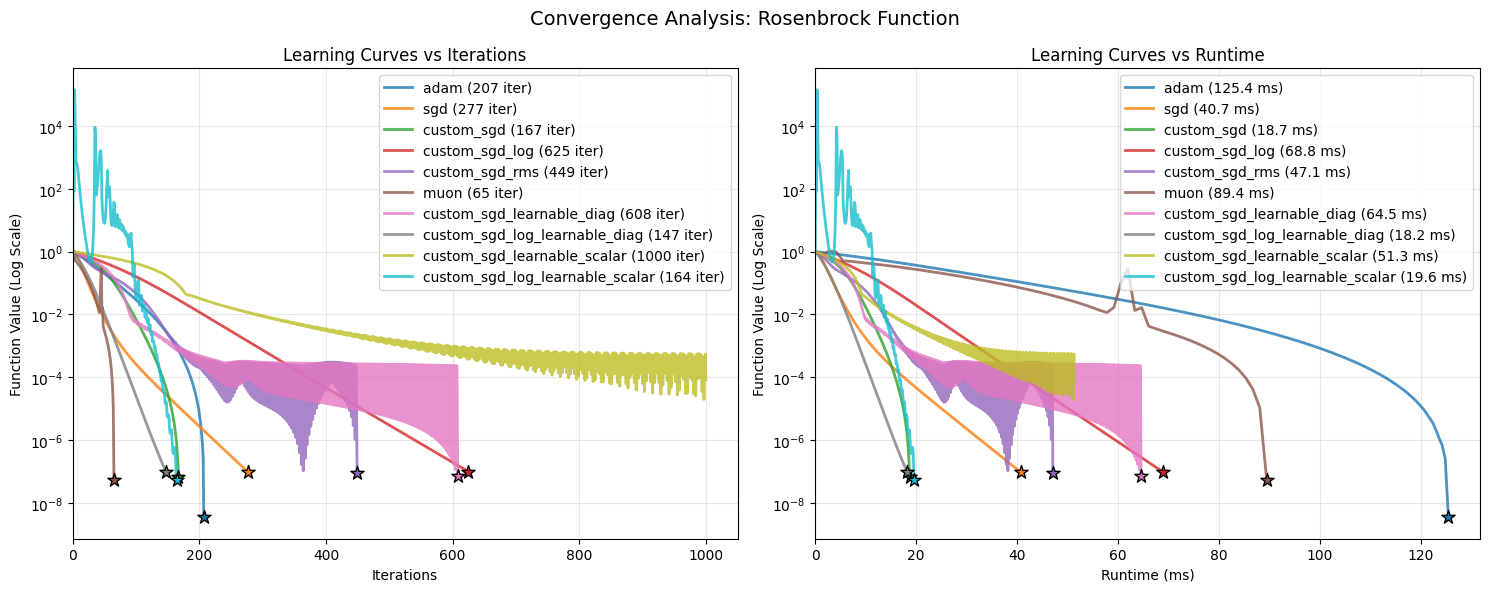


Rosenbrock Function Summary:
--------------------------------------------------
adam                           : ✓ Converged  |  207 iter |  125.4 ms | Final: 3.49e-09
sgd                            : ✓ Converged  |  277 iter |   40.7 ms | Final: 9.59e-08
custom_sgd                     : ✓ Converged  |  167 iter |   18.7 ms | Final: 6.74e-08
custom_sgd_log                 : ✓ Converged  |  625 iter |   68.8 ms | Final: 9.93e-08
custom_sgd_rms                 : ✓ Converged  |  449 iter |   47.1 ms | Final: 9.16e-08
muon                           : ✓ Converged  |   65 iter |   89.4 ms | Final: 5.33e-08
custom_sgd_learnable_diag      : ✓ Converged  |  608 iter |   64.5 ms | Final: 7.28e-08
custom_sgd_log_learnable_diag  : ✓ Converged  |  147 iter |   18.2 ms | Final: 9.93e-08
custom_sgd_learnable_scalar    : ✗ Failed     | 1000 iter |   51.3 ms | Final: 8.38e-05
custom_sgd_log_learnable_scalar: ✓ Converged  |  164 iter |   19.6 ms | Final: 5.45e-08


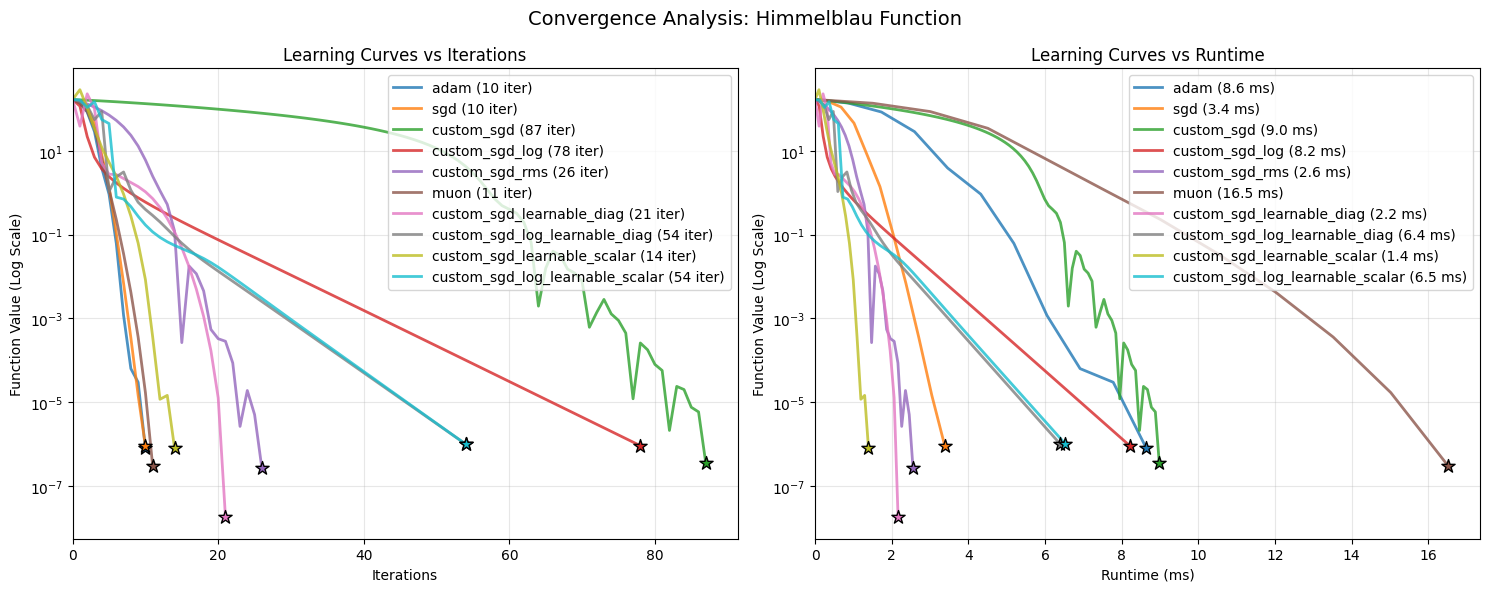


Himmelblau Function Summary:
--------------------------------------------------
adam                           : ✓ Converged  |   10 iter |    8.6 ms | Final: 7.85e-07
sgd                            : ✓ Converged  |   10 iter |    3.4 ms | Final: 8.97e-07
custom_sgd                     : ✓ Converged  |   87 iter |    9.0 ms | Final: 3.41e-07
custom_sgd_log                 : ✓ Converged  |   78 iter |    8.2 ms | Final: 9.08e-07
custom_sgd_rms                 : ✓ Converged  |   26 iter |    2.6 ms | Final: 2.64e-07
muon                           : ✓ Converged  |   11 iter |   16.5 ms | Final: 2.94e-07
custom_sgd_learnable_diag      : ✓ Converged  |   21 iter |    2.2 ms | Final: 1.76e-08
custom_sgd_log_learnable_diag  : ✓ Converged  |   54 iter |    6.4 ms | Final: 9.91e-07
custom_sgd_learnable_scalar    : ✓ Converged  |   14 iter |    1.4 ms | Final: 8.05e-07
custom_sgd_log_learnable_scalar: ✓ Converged  |   54 iter |    6.5 ms | Final: 9.90e-07


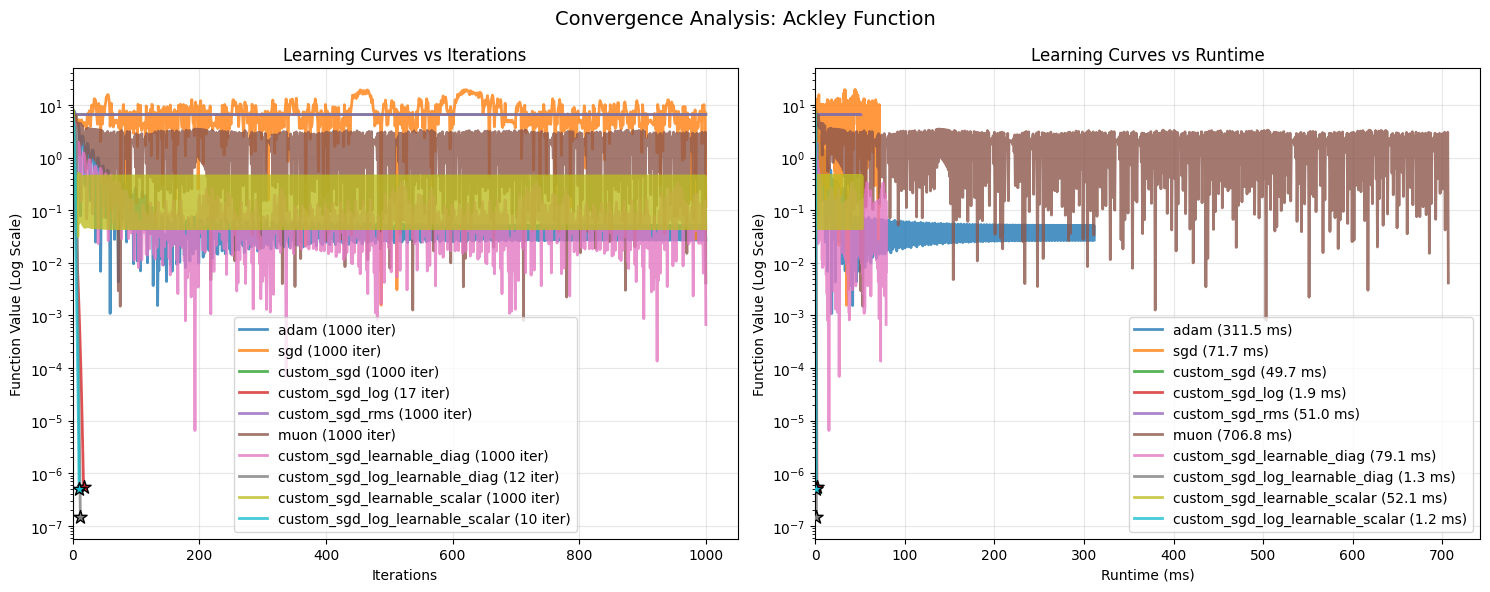


Ackley Function Summary:
--------------------------------------------------
adam                           : ✗ Failed     | 1000 iter |  311.5 ms | Final: 2.72e-02
sgd                            : ✗ Failed     | 1000 iter |   71.7 ms | Final: 1.19e-01
custom_sgd                     : ✗ Failed     | 1000 iter |   49.7 ms | Final: 6.56e+00
custom_sgd_log                 : ✓ Converged  |   17 iter |    1.9 ms | Final: 5.47e-07
custom_sgd_rms                 : ✗ Failed     | 1000 iter |   51.0 ms | Final: 6.56e+00
muon                           : ✗ Failed     | 1000 iter |  706.8 ms | Final: 4.15e-03
custom_sgd_learnable_diag      : ✗ Failed     | 1000 iter |   79.1 ms | Final: 6.73e-04
custom_sgd_log_learnable_diag  : ✓ Converged  |   12 iter |    1.3 ms | Final: 1.46e-07
custom_sgd_learnable_scalar    : ✗ Failed     | 1000 iter |   52.1 ms | Final: 4.49e-02
custom_sgd_log_learnable_scalar: ✓ Converged  |   10 iter |    1.2 ms | Final: 5.00e-07


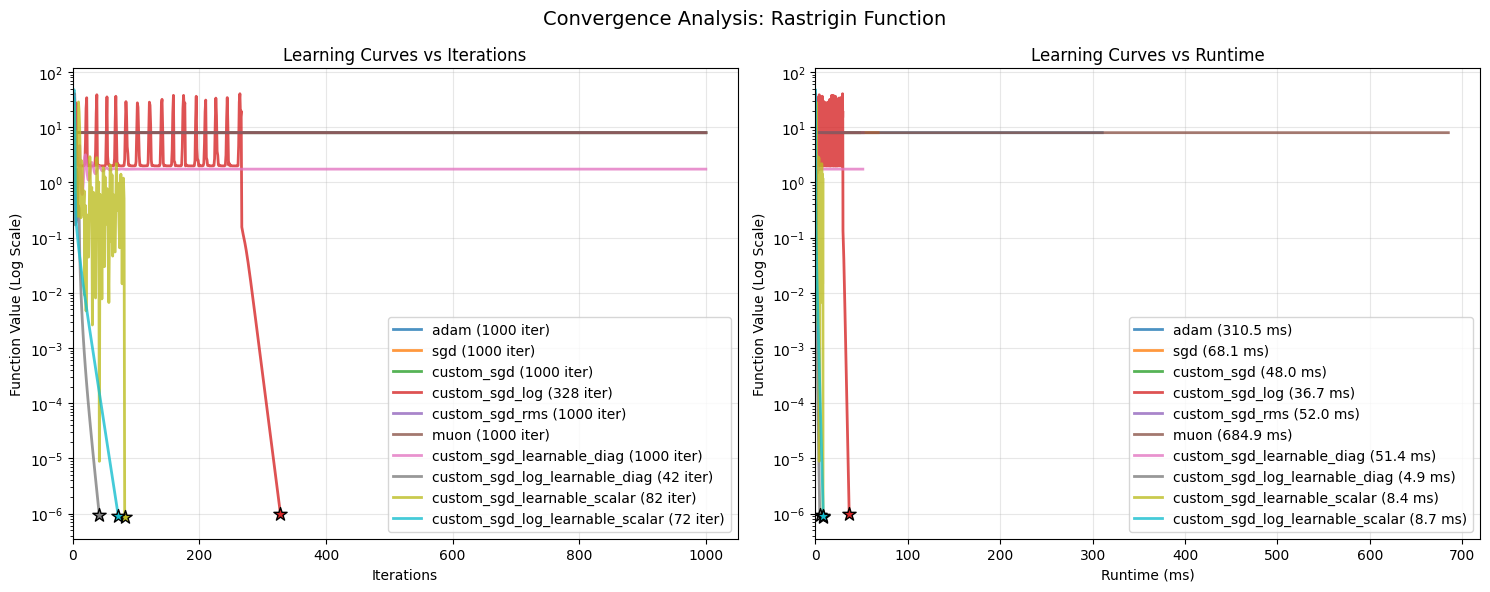


Rastrigin Function Summary:
--------------------------------------------------
adam                           : ✗ Failed     | 1000 iter |  310.5 ms | Final: 7.96e+00
sgd                            : ✗ Failed     | 1000 iter |   68.1 ms | Final: 7.96e+00
custom_sgd                     : ✗ Failed     | 1000 iter |   48.0 ms | Final: 7.96e+00
custom_sgd_log                 : ✓ Converged  |  328 iter |   36.7 ms | Final: 9.97e-07
custom_sgd_rms                 : ✗ Failed     | 1000 iter |   52.0 ms | Final: 7.96e+00
muon                           : ✗ Failed     | 1000 iter |  684.9 ms | Final: 7.96e+00
custom_sgd_learnable_diag      : ✗ Failed     | 1000 iter |   51.4 ms | Final: 1.74e+00
custom_sgd_log_learnable_diag  : ✓ Converged  |   42 iter |    4.9 ms | Final: 9.26e-07
custom_sgd_learnable_scalar    : ✓ Converged  |   82 iter |    8.4 ms | Final: 8.54e-07
custom_sgd_log_learnable_scalar: ✓ Converged  |   72 iter |    8.7 ms | Final: 8.89e-07


In [17]:
# Plot convergence curves using Optuna results
for function_name in test_functions.keys():
    plot_convergence_curves(optuna_results, function_name)

In [15]:
# Summary report
print("=" * 80)
print("OPTUNA OPTIMIZATION COMPREHENSIVE SUMMARY")
print("=" * 80)

# Overall rankings
print("\n1. BY CONVERGENCE RATE:")
optuna_convergence_ranking = optuna_df.groupby('optimiser')['converged'].mean().sort_values(ascending=False)
for i, (optimiser, rate) in enumerate(optuna_convergence_ranking.items(), 1):
    print(f"{i}. {optimiser:35s}: {rate:.1%}")

optuna_converged_df = optuna_df[optuna_df['converged'] == True]
if len(optuna_converged_df) > 0:
    print("\n2. BY AVERAGE ITERATIONS (converged runs only):")
    optuna_iteration_ranking = optuna_converged_df.groupby('optimiser')['iterations'].mean().sort_values()
    for i, (optimiser, avg_iter) in enumerate(optuna_iteration_ranking.items(), 1):
        print(f"{i}. {optimiser:35s}: {avg_iter:.1f} iterations")

    print("\n3. BY AVERAGE RUNTIME (converged runs only):")
    optuna_runtime_ranking = optuna_converged_df.groupby('optimiser')['runtime_ms'].mean().sort_values()
    for i, (optimiser, avg_runtime) in enumerate(optuna_runtime_ranking.items(), 1):
        print(f"{i}. {optimiser:35s}: {avg_runtime:.1f} ms")

print(f"\n{'='*80}")
print("KEY INSIGHTS:")
print("=" * 80)

total_experiments = len(optuna_df)
total_converged = optuna_df['converged'].sum()
convergence_rate = total_converged / total_experiments

print(f"• Total experiments: {total_experiments}")
print(f"• Overall convergence rate: {convergence_rate:.1%}")
print(f"• Most reliable optimizer: {optuna_convergence_ranking.index[0]} ({optuna_convergence_ranking.iloc[0]:.1%} success)")

if len(optuna_converged_df) > 0:
    fastest_optimiser = optuna_iteration_ranking.index[0]
    fastest_iterations = optuna_iteration_ranking.iloc[0]
    print(f"• Fastest optimizer (iterations): {fastest_optimiser} ({fastest_iterations:.1f} avg)")
    
    quickest_optimiser = optuna_runtime_ranking.index[0]
    quickest_runtime = optuna_runtime_ranking.iloc[0]
    print(f"• Quickest optimizer (runtime): {quickest_optimiser} ({quickest_runtime:.1f} ms avg)")

# Function difficulty ranking
optuna_function_difficulty = optuna_df.groupby('function')['converged'].mean().sort_values()
print(f"• Most challenging function: {optuna_function_difficulty.index[0]} ({optuna_function_difficulty.iloc[0]:.1%} success)")
print(f"• Easiest function: {optuna_function_difficulty.index[-1]} ({optuna_function_difficulty.iloc[-1]:.1%} success)")

print(f"\n{'='*80}")

OPTUNA OPTIMIZATION COMPREHENSIVE SUMMARY

1. BY CONVERGENCE RATE:
1. custom_sgd_log                     : 100.0%
2. custom_sgd_log_learnable_diag      : 100.0%
3. custom_sgd_log_learnable_scalar    : 100.0%
4. adam                               : 60.0%
5. custom_sgd                         : 60.0%
6. custom_sgd_learnable_diag          : 60.0%
7. custom_sgd_learnable_scalar        : 60.0%
8. custom_sgd_rms                     : 60.0%
9. sgd                                : 60.0%
10. muon                               : 40.0%

2. BY AVERAGE ITERATIONS (converged runs only):
1. muon                               : 38.0 iterations
2. custom_sgd_learnable_scalar        : 56.0 iterations
3. custom_sgd_log_learnable_diag      : 64.2 iterations
4. custom_sgd_log_learnable_scalar    : 75.4 iterations
5. adam                               : 92.3 iterations
6. sgd                                : 128.0 iterations
7. custom_sgd                         : 143.3 iterations
8. custom_sgd_rms         

## Hyperparameter Optimization with Optuna

In [24]:
import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner

# Configuration for Optuna
N_TRIALS = 200 if RUN_FULL_EXPERIMENT else 50
N_STARTUP_TRIALS = 20 if RUN_FULL_EXPERIMENT else 10
TIMEOUT = None  # No timeout, run all trials
USE_PRUNING = True

def create_objective(optimiser_type: str, function_name: str, function_info: dict):
    """Create an Optuna objective function for a specific optimiser and test function"""
    
    def objective(trial: optuna.Trial) -> float:
        # Sample hyperparameters based on optimiser type
        if optimiser_type == 'adam':
            lr = trial.suggest_float('learning_rate', 1e-6, 10.0, log=True)
            b1 = trial.suggest_float('b1', 0.0, 0.99)
            b2 = trial.suggest_float('b2', 0.8, 0.999)
            eps = trial.suggest_float('eps', 1e-10, 1e-6, log=True)
            opt = optax.adam(learning_rate=lr, b1=b1, b2=b2, eps=eps)
            config = {'learning_rate': lr, 'b1': b1, 'b2': b2, 'eps': eps}
            
        elif optimiser_type == 'sgd':
            lr = trial.suggest_float('learning_rate', 1e-6, 10.0, log=True)
            momentum = trial.suggest_float('momentum', 0.0, 0.99)
            opt = optax.sgd(learning_rate=lr, momentum=momentum)
            config = {'learning_rate': lr, 'momentum': momentum}
            
        elif optimiser_type in ['custom_sgd', 'custom_sgd_log']:
            lr = trial.suggest_float('learning_rate', 1e-6, 10.0, log=True)
            momentum = trial.suggest_float('momentum', 0.0, 0.99)
            xi = trial.suggest_float('xi', 0.01, 10.0, log=True)
            beta = trial.suggest_float('beta', 0.0, 0.99)
            
            if optimiser_type == 'custom_sgd':
                from optimisers.jax_fixed import custom_sgd
                opt = custom_sgd(learning_rate=lr, momentum=momentum, xi=xi, beta=beta)
            else:
                from optimisers.jax_fixed import custom_sgd_log
                opt = custom_sgd_log(learning_rate=lr, momentum=momentum, xi=xi, beta=beta)
            config = {'learning_rate': lr, 'momentum': momentum, 'xi': xi, 'beta': beta}
            
        elif optimiser_type in ['custom_sgd_rms', 'custom_sgd_log_rms']:
            lr = trial.suggest_float('learning_rate', 1e-6, 10.0, log=True)
            momentum = trial.suggest_float('momentum', 0.0, 0.99)
            xi = trial.suggest_float('xi', 0.01, 10.0, log=True)
            beta = trial.suggest_float('beta', 0.0, 0.99)
            beta_rms = trial.suggest_float('beta_rms', 0.8, 0.999)
            eps = trial.suggest_float('eps', 1e-10, 1e-6, log=True)
            
            if optimiser_type == 'custom_sgd_rms':
                from optimisers.jax_fixed import custom_sgd_rms
                opt = custom_sgd_rms(learning_rate=lr, momentum=momentum, xi=xi, beta=beta, beta_rms=beta_rms, eps=eps)
            else:
                from optimisers.jax_fixed import custom_sgd_log_rms
                opt = custom_sgd_log_rms(learning_rate=lr, momentum=momentum, xi=xi, beta=beta, beta_rms=beta_rms, eps=eps)
            config = {'learning_rate': lr, 'momentum': momentum, 'xi': xi, 'beta': beta, 'beta_rms': beta_rms, 'eps': eps}
            
        elif optimiser_type in ['custom_sgd_learnable_diag', 'custom_sgd_log_learnable_diag']:
            lr = trial.suggest_float('learning_rate', 1e-6, 10.0, log=True)
            momentum = trial.suggest_float('momentum', 0.0, 0.99)
            xi = trial.suggest_float('xi', 0.01, 10.0, log=True)
            beta = trial.suggest_float('beta', 0.0, 0.99)
            metric_lr = trial.suggest_float('metric_lr', 1e-5, 1e-2, log=True)
            metric_reg = trial.suggest_float('metric_reg', 1e-6, 1e-2, log=True)
            metric_clip = trial.suggest_float('metric_clip', 1.0, 10.0)
            
            if optimiser_type == 'custom_sgd_learnable_diag':
                from optimisers.jax_learnable_diag import custom_sgd_learnable_diag
                opt = custom_sgd_learnable_diag(
                    learning_rate=lr, momentum=momentum, xi=xi, beta=beta,
                    metric_lr=metric_lr, metric_reg=metric_reg, metric_clip=metric_clip
                )
            else:
                from optimisers.jax_learnable_diag import custom_sgd_log_learnable_diag
                opt = custom_sgd_log_learnable_diag(
                    learning_rate=lr, momentum=momentum, xi=xi, beta=beta,
                    metric_lr=metric_lr, metric_reg=metric_reg, metric_clip=metric_clip
                )
            config = {
                'learning_rate': lr, 'momentum': momentum, 'xi': xi, 'beta': beta,
                'metric_lr': metric_lr, 'metric_reg': metric_reg, 'metric_clip': metric_clip
            }
            
        elif optimiser_type in ['custom_sgd_learnable_scalar', 'custom_sgd_log_learnable_scalar']:
            lr = trial.suggest_float('learning_rate', 1e-6, 10.0, log=True)
            momentum = trial.suggest_float('momentum', 0.0, 0.99)
            xi = trial.suggest_float('xi', 0.01, 10.0, log=True)
            beta = trial.suggest_float('beta', 0.0, 0.99)
            metric_lr = trial.suggest_float('metric_lr', 1e-5, 1e-2, log=True)
            metric_reg = trial.suggest_float('metric_reg', 1e-6, 1e-2, log=True)
            metric_clip = trial.suggest_float('metric_clip', 1.0, 10.0)
            
            if optimiser_type == 'custom_sgd_learnable_scalar':
                from optimisers.jax_learnable_scalar import custom_sgd_learnable_scalar
                opt = custom_sgd_learnable_scalar(
                    learning_rate=lr, momentum=momentum, xi=xi, beta=beta,
                    metric_lr=metric_lr, metric_reg=metric_reg, metric_clip=metric_clip
                )
            else:
                from optimisers.jax_learnable_scalar import custom_sgd_log_learnable_scalar
                opt = custom_sgd_log_learnable_scalar(
                    learning_rate=lr, momentum=momentum, xi=xi, beta=beta,
                    metric_lr=metric_lr, metric_reg=metric_reg, metric_clip=metric_clip
                )
            config = {
                'learning_rate': lr, 'momentum': momentum, 'xi': xi, 'beta': beta,
                'metric_lr': metric_lr, 'metric_reg': metric_reg, 'metric_clip': metric_clip
            }
        else:
            raise ValueError(f"Unknown optimiser type: {optimiser_type}")
        
        # Add function name to function_info for the run_optimiser_on_function
        func_info_with_name = function_info.copy()
        func_info_with_name['name'] = function_name
        
        # Run optimization using the existing run_optimiser_on_function
        result = run_optimiser_on_function(
            optimiser_name=optimiser_type,
            optimiser=opt,
            function_info=func_info_with_name,
            config=config
        )
        
        # Optuna minimizes, so we want to minimize based on:
        # 1. Convergence (penalize non-convergence heavily)
        # 2. Iterations (fewer is better)
        # 3. Final value (lower is better)
        if result.converged:
            objective_value = result.iterations + result.final_value * 0.1
        else:
            objective_value = 10000 + result.final_value
        
        # Store the result for later analysis
        trial.set_user_attr('result', result)
        
        # Optionally prune based on intermediate iterations
        if USE_PRUNING and result.iterations > 500:
            raise optuna.TrialPruned()
        
        return objective_value
    
    return objective

print("OPTUNA HYPERPARAMETER OPTIMIZATION CONFIGURATION")
print("=" * 50)
print(f"Mode: {'FULL EXPERIMENT' if RUN_FULL_EXPERIMENT else 'DEMO EXPERIMENT'}")
print(f"Trials per optimiser-function combination: {N_TRIALS}")
print(f"Startup trials (random sampling): {N_STARTUP_TRIALS}")
print(f"Using pruning: {USE_PRUNING}")
print(f"Test Functions: {len(test_functions)} ({', '.join(test_functions.keys())})")
print(f"Optimisers: 8 (adam, sgd, custom_sgd variants, learnable variants)")
print(f"Total trials: {N_TRIALS * 8 * len(test_functions)}")
print(f"Estimated runtime: ~{N_TRIALS * 8 * len(test_functions) * 0.2 / 60:.1f} minutes")
print("=" * 50)

# Run Optuna optimization
optuna.logging.set_verbosity(optuna.logging.WARNING)  # Reduce verbosity

optuna_studies = {}
optuna_results = []

# Note: Removed 'muon' and 'custom_sgd_log_rms' as they don't exist in the codebase
optimiser_types = [
    'adam', 'sgd', 'custom_sgd', 'custom_sgd_log', 
    'custom_sgd_rms',
    'custom_sgd_learnable_diag', 'custom_sgd_log_learnable_diag',
    'custom_sgd_learnable_scalar', 'custom_sgd_log_learnable_scalar'
]

total_studies = len(optimiser_types) * len(test_functions)
completed = 0

print(f"\nRunning {total_studies} optimization studies...")

for function_name, function_info in test_functions.items():
    for optimiser_type in optimiser_types:
        study_name = f"{optimiser_type}_{function_name}"
        
        # Create study with TPE sampler and optional median pruner
        sampler = TPESampler(n_startup_trials=N_STARTUP_TRIALS, seed=42)
        pruner = MedianPruner(n_startup_trials=N_STARTUP_TRIALS) if USE_PRUNING else optuna.pruners.NopPruner()
        
        study = optuna.create_study(
            study_name=study_name,
            direction='minimize',
            sampler=sampler,
            pruner=pruner
        )
        
        # Optimize
        objective = create_objective(optimiser_type, function_name, function_info)
        study.optimize(objective, n_trials=N_TRIALS, timeout=TIMEOUT, show_progress_bar=False)
        
        # Store study
        optuna_studies[study_name] = study
        
        # Extract all results from trials
        for trial in study.trials:
            if trial.state == optuna.trial.TrialState.COMPLETE:
                result = trial.user_attrs.get('result')
                if result is not None:
                    optuna_results.append(result)
        
        completed += 1
        if completed % 10 == 0:
            print(f"  Completed {completed}/{total_studies} studies...")

print(f"\nCompleted all {total_studies} studies!")
print(f"Total optimization runs: {len(optuna_results)}")

# Use the same variable name as the old grid search for compatibility
results = optuna_results

OPTUNA HYPERPARAMETER OPTIMIZATION CONFIGURATION
Mode: DEMO EXPERIMENT
Trials per optimiser-function combination: 50
Startup trials (random sampling): 10
Using pruning: True
Test Functions: 5 (beale, rosenbrock, himmelblau, ackley, rastrigin)
Optimisers: 8 (adam, sgd, custom_sgd variants, learnable variants)
Total trials: 2000
Estimated runtime: ~6.7 minutes

Running 45 optimization studies...
  Completed 10/45 studies...
  Completed 10/45 studies...
  Completed 20/45 studies...
  Completed 20/45 studies...
  Completed 30/45 studies...
  Completed 30/45 studies...
  Completed 40/45 studies...
  Completed 40/45 studies...

Completed all 45 studies!
Total optimization runs: 346

Completed all 45 studies!
Total optimization runs: 346


## Results Analysis

In [25]:
def analyse_results(results: List[OptimisationResult]) -> pd.DataFrame:
    """Convert results to DataFrame for analysis"""
    data = []
    for result in results:
        data.append({
            'optimiser': result.optimiser_name,
            'function': result.function_name,
            'converged': result.converged,
            'iterations': result.iterations,
            'final_value': result.final_value,
            'runtime_seconds': result.runtime_seconds,
            'runtime_ms': result.runtime_seconds * 1000,
            'config': str(result.config)
        })
    return pd.DataFrame(data)

def get_best_results(df: pd.DataFrame) -> pd.DataFrame:
    """Get best result for each optimiser-function combination"""
    best_results = []
    
    for (optimiser, function), group in df.groupby(['optimiser', 'function']):
        # First priority: converged runs (by iterations)
        converged = group[group['converged'] == True]
        if len(converged) > 0:
            best = converged.loc[converged['iterations'].idxmin()]
        else:
            # Second priority: non-converged runs (by final value)
            best = group.loc[group['final_value'].idxmin()]
        
        best_results.append(best)
    
    return pd.DataFrame(best_results)

# Analyse results
df = analyse_results(results)
best_df = get_best_results(df)

print("Results Summary:")
print(f"Total experiments: {len(df)}")
print(f"Unique optimiser-function combinations: {len(best_df)}")
print(f"Overall convergence rate: {df['converged'].mean():.2%}")

print("\nConvergence by optimiser:")
convergence_by_opt = df.groupby('optimiser')['converged'].agg(['count', 'sum', 'mean'])
convergence_by_opt.columns = ['total_runs', 'converged_runs', 'convergence_rate']
print(convergence_by_opt)

print("\nConvergence by function:")
convergence_by_func = df.groupby('function')['converged'].agg(['count', 'sum', 'mean'])
convergence_by_func.columns = ['total_runs', 'converged_runs', 'convergence_rate']
print(convergence_by_func)

Results Summary:
Total experiments: 346
Unique optimiser-function combinations: 22
Overall convergence rate: 100.00%

Convergence by optimiser:
                                 total_runs  converged_runs  convergence_rate
optimiser                                                                    
adam                                     31              31               1.0
custom_sgd                               25              25               1.0
custom_sgd_learnable_diag                 9               9               1.0
custom_sgd_learnable_scalar               3               3               1.0
custom_sgd_log                           54              54               1.0
custom_sgd_log_learnable_diag            63              63               1.0
custom_sgd_log_learnable_scalar          94              94               1.0
custom_sgd_rms                           29              29               1.0
sgd                                      38              38               1.

Optimiser: adam, Convergence Rate: 100.00%, Avg Iterations: 162.0, Avg Runtime: 95.1 ms, Performance Score: 17.15
Optimiser: custom_sgd, Convergence Rate: 100.00%, Avg Iterations: 86.0, Avg Runtime: 8.7 ms, Performance Score: 8.69
Optimiser: custom_sgd_learnable_diag, Convergence Rate: 100.00%, Avg Iterations: 162.0, Avg Runtime: 16.5 ms, Performance Score: 16.36
Optimiser: custom_sgd_learnable_scalar, Convergence Rate: 100.00%, Avg Iterations: 148.0, Avg Runtime: 14.8 ms, Performance Score: 14.95
Optimiser: custom_sgd_log, Convergence Rate: 100.00%, Avg Iterations: 41.7, Avg Runtime: 4.5 ms, Performance Score: 4.21
Optimiser: custom_sgd_log_learnable_diag, Convergence Rate: 100.00%, Avg Iterations: 36.2, Avg Runtime: 4.4 ms, Performance Score: 3.67
Optimiser: custom_sgd_log_learnable_scalar, Convergence Rate: 100.00%, Avg Iterations: 36.8, Avg Runtime: 4.4 ms, Performance Score: 3.72
Optimiser: custom_sgd_rms, Convergence Rate: 100.00%, Avg Iterations: 169.3, Avg Runtime: 17.6 ms, Per

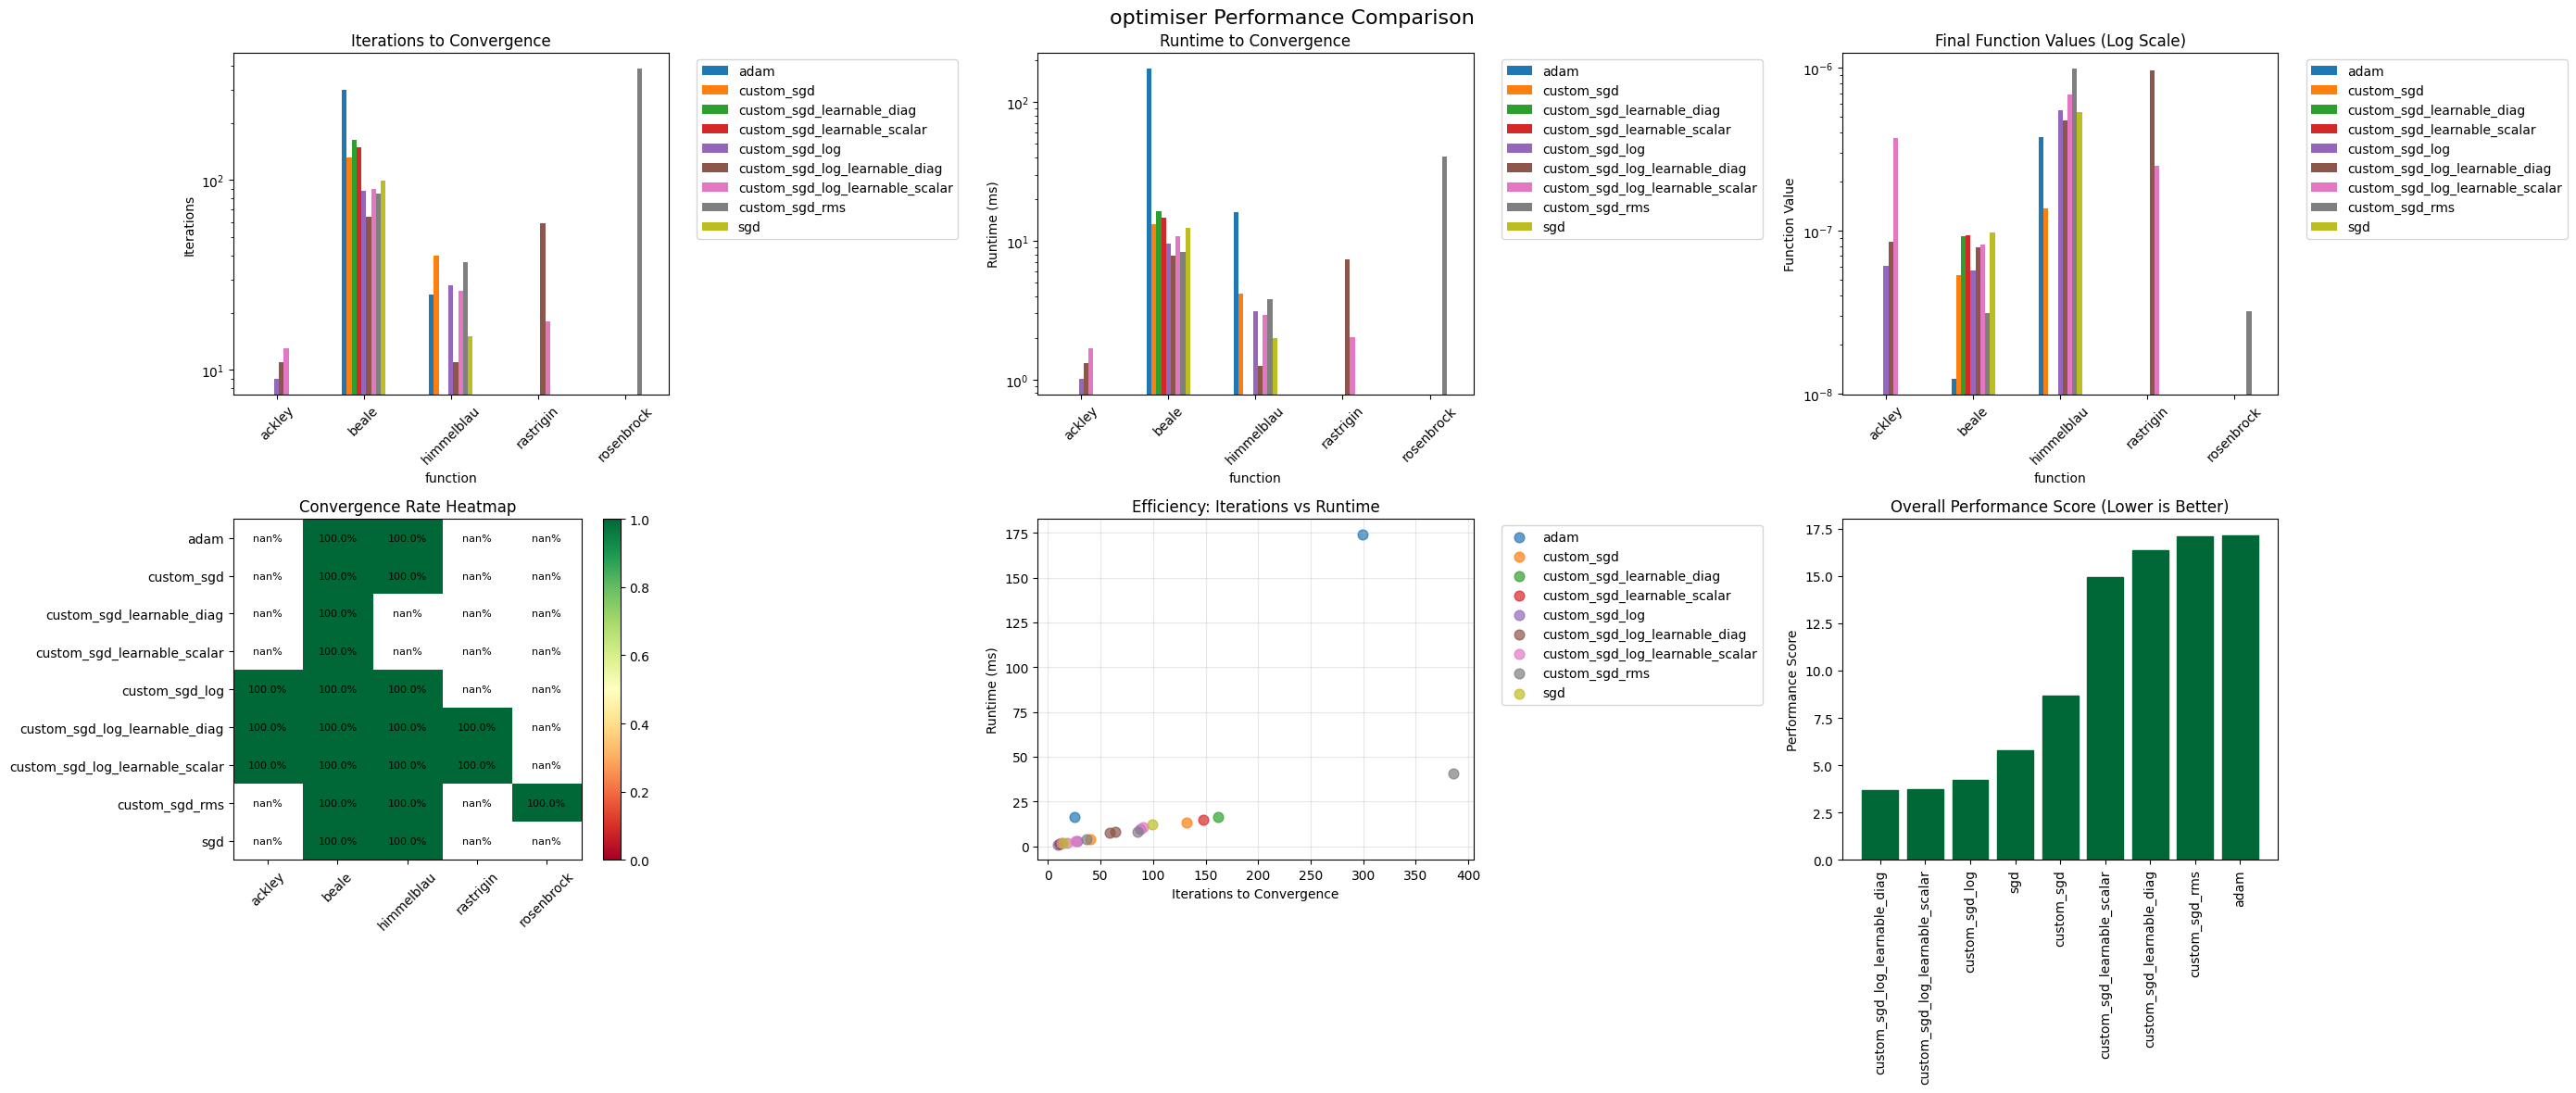

In [26]:
# Performance comparison visualization
fig, axes = plt.subplots(2, 3, figsize=(28, 12))
fig.suptitle('optimiser Performance Comparison', fontsize=16)

# 1. Iterations to convergence (converged runs only)
ax = axes[0, 0]
converged_best = best_df[best_df['converged'] == True]
if len(converged_best) > 0:
    pivot_iterations = converged_best.pivot(index='function', columns='optimiser', values='iterations')
    pivot_iterations.plot(kind='bar', ax=ax, rot=45)
    ax.set_title('Iterations to Convergence')
    ax.set_ylabel('Iterations')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.set_yscale('log')

# 2. Runtime comparison
ax = axes[0, 1]
converged_best = best_df[best_df['converged'] == True]
if len(converged_best) > 0:
    pivot_runtime = converged_best.pivot(index='function', columns='optimiser', values='runtime_ms')
    pivot_runtime.plot(kind='bar', ax=ax, rot=45)
    ax.set_title('Runtime to Convergence')
    ax.set_ylabel('Runtime (ms)')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.set_yscale('log')

# 3. Final values (all runs)
ax = axes[0, 2]
pivot_values = best_df.pivot(index='function', columns='optimiser', values='final_value')
pivot_values.plot(kind='bar', ax=ax, rot=45, logy=True)
ax.set_title('Final Function Values (Log Scale)')
ax.set_ylabel('Function Value')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# 4. Convergence rate heatmap
ax = axes[1, 0]
convergence_matrix = df.groupby(['optimiser', 'function'])['converged'].mean().unstack()
im = ax.imshow(convergence_matrix.values, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
ax.set_xticks(range(len(convergence_matrix.columns)))
ax.set_xticklabels(convergence_matrix.columns, rotation=45)
ax.set_yticks(range(len(convergence_matrix.index)))
ax.set_yticklabels(convergence_matrix.index)
ax.set_title('Convergence Rate Heatmap')
plt.colorbar(im, ax=ax)

# Add text annotations
for i in range(len(convergence_matrix.index)):
    for j in range(len(convergence_matrix.columns)):
        text = ax.text(j, i, f'{convergence_matrix.iloc[i, j]:.1%}',
                      ha="center", va="center", color="black", fontsize=8)

# 5. Efficiency scatter plot (iterations vs runtime for converged runs)
ax = axes[1, 1]
for optimiser in converged_best['optimiser'].unique():
    opt_data = converged_best[converged_best['optimiser'] == optimiser]
    ax.scatter(opt_data['iterations'], opt_data['runtime_ms'], 
              label=optimiser, alpha=0.7, s=60)

ax.set_xlabel('Iterations to Convergence')
ax.set_ylabel('Runtime (ms)')
ax.set_title('Efficiency: Iterations vs Runtime')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)

# 6. Overall performance ranking
ax = axes[1, 2]
# Calculate performance score (lower is better)
performance_scores = []
for optimiser in best_df['optimiser'].unique():
    opt_data = best_df[best_df['optimiser'] == optimiser]
    converged_rate = opt_data['converged'].mean()
    avg_iterations = opt_data[opt_data['converged']]['iterations'].mean() if len(opt_data[opt_data['converged']]) > 0 else 1000
    avg_runtime = opt_data[opt_data['converged']]['runtime_ms'].mean() if len(opt_data[opt_data['converged']]) > 0 else 1000
    
    # Performance score combines convergence rate (higher is better) and speed (lower is better)
    score = (1 - converged_rate) * 1000 + avg_iterations * 0.1 + avg_runtime * 0.01
    performance_scores.append({'optimiser': optimiser, 'score': score, 'convergence_rate': converged_rate})

    print(f"Optimiser: {optimiser}, Convergence Rate: {converged_rate:.2%}, Avg Iterations: {avg_iterations:.1f}, Avg Runtime: {avg_runtime:.1f} ms, Performance Score: {score:.2f}")

performance_df = pd.DataFrame(performance_scores).sort_values('score')
bars = ax.bar(performance_df['optimiser'], performance_df['score'])
ax.set_title('Overall Performance Score (Lower is Better)')
ax.set_ylabel('Performance Score')
ax.tick_params(axis='x', rotation=90)

# Color bars by convergence rate
colors = plt.cm.RdYlGn(performance_df['convergence_rate'])
for bar, color in zip(bars, colors):
    bar.set_color(color)

plt.tight_layout()
plt.show()

In [16]:
# Convergence analysis with learning curves
def plot_convergence_curves(results: List[OptimisationResult], function_name: str):
    """Plot convergence curves for all optimisers on a specific function"""
    
    # Get best result for each optimiser on this function
    function_results = [r for r in results if r.function_name == function_name]
    best_results_by_optimiser = {}
    
    for result in function_results:
        optimiser = result.optimiser_name
        if optimiser not in best_results_by_optimiser:
            best_results_by_optimiser[optimiser] = result
        else:
            # Compare results: prioritise converged, then by iterations/final value
            current_best = best_results_by_optimiser[optimiser]
            if (result.converged and not current_best.converged) or \
               (result.converged == current_best.converged and 
                (result.iterations < current_best.iterations if result.converged else 
                 result.final_value < current_best.final_value)):
                best_results_by_optimiser[optimiser] = result
    
    # Create only the first two plots
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    fig.suptitle(f'Convergence Analysis: {function_name.title()} Function', fontsize=14)
    
    colours = plt.cm.tab10(np.linspace(0, 1, len(best_results_by_optimiser)))
    
    # Plot 1: Learning curves vs iterations (log scale)
    ax1 = axes[0]
    for (optimiser, result), colour in zip(best_results_by_optimiser.items(), colours):
        history = result.convergence_history
        iterations = range(len(history))
        
        # Plot learning curve
        ax1.semilogy(iterations, history, label=f'{optimiser} ({result.iterations} iter)', 
                    color=colour, linewidth=2, alpha=0.8)
        
        # Mark convergence point if converged
        if result.converged:
            conv_iter = result.iterations
            conv_value = history[conv_iter]
            ax1.scatter(conv_iter, conv_value, color=colour, s=100, marker='*', 
                       edgecolor='black', linewidth=1, zorder=10)
    
    ax1.set_xlabel('Iterations')
    ax1.set_ylabel('Function Value (Log Scale)')
    ax1.set_title('Learning Curves vs Iterations')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(left=0)
    # ax1.set_ylim(bottom=1e-8)
    
    # Plot 2: Learning curves vs runtime (log scale)
    ax2 = axes[1]
    for (optimiser, result), colour in zip(best_results_by_optimiser.items(), colours):
        history = result.convergence_history
        # Create time axis based on total runtime
        time_points = np.linspace(0, result.runtime_seconds * 1000, len(history))
        
        # Plot learning curve vs time
        ax2.semilogy(time_points, history, label=f'{optimiser} ({result.runtime_seconds*1000:.1f} ms)', 
                    color=colour, linewidth=2, alpha=0.8)
        
        # Mark convergence point if converged
        if result.converged:
            conv_time = time_points[result.iterations]
            conv_value = history[result.iterations]
            ax2.scatter(conv_time, conv_value, color=colour, s=100, marker='*',
                       edgecolor='black', linewidth=1, zorder=10)
    
    ax2.set_xlabel('Runtime (ms)')
    ax2.set_ylabel('Function Value (Log Scale)')
    ax2.set_title('Learning Curves vs Runtime')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.set_xlim(left=0)
    # ax2.set_ylim(bottom=1e-8)
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print(f"\n{function_name.title()} Function Summary:")
    print("-" * 50)
    for optimiser, result in best_results_by_optimiser.items():
        status = "✓ Converged" if result.converged else "✗ Failed"
        print(f"{optimiser:31s}: {status:12s} | {result.iterations:4d} iter | "
              f"{result.runtime_seconds*1000:6.1f} ms | Final: {result.final_value:.2e}")

# Plot convergence curves for each function
for function_name in test_functions.keys():
    plot_convergence_curves(results, function_name)


NameError: name 'results' is not defined

In [ ]:
#
print("=" * 80)
print("COMPREHENSIVE OPTIMISATION EXPERIMENT RESULTS")
print("=" * 80)

# Create summary table
summary_data = []
for function_name in test_functions.keys():
    function_results = [r for r in results if r.function_name == function_name]
    best_results_by_optimiser = {}
    
    for result in function_results:
        optimiser = result.optimiser_name
        if optimiser not in best_results_by_optimiser:
            best_results_by_optimiser[optimiser] = result
        else:
            current_best = best_results_by_optimiser[optimiser]
            if (result.converged and not current_best.converged) or \
               (result.converged == current_best.converged and 
                (result.iterations < current_best.iterations if result.converged else 
                 result.final_value < current_best.final_value)):
                best_results_by_optimiser[optimiser] = result
    
    for optimiser, result in best_results_by_optimiser.items():
        summary_data.append({
            'Function': function_name,
            'optimiser': optimiser,
            'Converged': result.converged,
            'Iterations': result.iterations,
            'Runtime (ms)': result.runtime_seconds * 1000,
            'Time per Iteration (ms)': (result.runtime_seconds * 1000) / result.iterations if result.iterations > 0 else 0,
            'Final Value': result.final_value,
            'Efficiency': result.iterations / (result.runtime_seconds * 1000) if result.runtime_seconds > 0 else 0
        })

summary_df = pd.DataFrame(summary_data)

# Display results by function
for function_name in test_functions.keys():
    print(f"\n{function_name.upper()} FUNCTION:")
    print("-" * 40)
    func_data = summary_df[summary_df['Function'] == function_name].sort_values('Iterations')
    for _, row in func_data.iterrows():
        status = "✓" if row['Converged'] else "✗"
        print(f"{status} {row['optimiser']:15s}: {row['Iterations']:4d} iter | "
              f"{row['Runtime (ms)']:6.1f} ms | {row['Final Value']:.2e}")

print(f"\n{'='*80}")
print("OVERALL RANKINGS:")
print("=" * 80)

# Overall performance ranking
print("\n1. BY CONVERGENCE RATE:")
convergence_ranking = summary_df.groupby('optimiser')['Converged'].mean().sort_values(ascending=False)
for i, (optimiser, rate) in enumerate(convergence_ranking.items(), 1):
    print(f"{i}. {optimiser:15s}: {rate:.1%}")

print("\n2. BY AVERAGE ITERATIONS (converged runs only):")
converged_df = summary_df[summary_df['Converged'] == True]
if len(converged_df) > 0:
    iteration_ranking = converged_df.groupby('optimiser')['Iterations'].mean().sort_values()
    for i, (optimiser, avg_iter) in enumerate(iteration_ranking.items(), 1):
        print(f"{i}. {optimiser:15s}: {avg_iter:.1f} iterations")

print("\n3. BY AVERAGE RUNTIME (converged runs only):")
if len(converged_df) > 0:
    runtime_ranking = converged_df.groupby('optimiser')['Runtime (ms)'].mean().sort_values()
    for i, (optimiser, avg_runtime) in enumerate(runtime_ranking.items(), 1):
        print(f"{i}. {optimiser:15s}: {avg_runtime:.1f} ms")

print("\n4. BY AVERAGE TIME PER ITERATION (converged runs only):")
if len(converged_df) > 0:
    time_per_iter_ranking = converged_df.groupby('optimiser')['Time per Iteration (ms)'].mean().sort_values()
    for i, (optimiser, avg_time_per_iter) in enumerate(time_per_iter_ranking.items(), 1):
        print(f"{i}. {optimiser:15s}: {avg_time_per_iter:.3f} ms/iter")

print(f"\n{'='*80}")
print("KEY INSIGHTS:")
print("=" * 80)

# Generate insights
total_experiments = len(summary_df)
total_converged = summary_df['Converged'].sum()
convergence_rate = total_converged / total_experiments

print(f"• Total experiments: {total_experiments}")
print(f"• Overall convergence rate: {convergence_rate:.1%}")
print(f"• Most reliable optimiser: {convergence_ranking.index[0]} ({convergence_ranking.iloc[0]:.1%} success)")

if len(converged_df) > 0:
    fastest_optimiser = iteration_ranking.index[0]
    fastest_iterations = iteration_ranking.iloc[0]
    print(f"• Fastest optimiser (iterations): {fastest_optimiser} ({fastest_iterations:.1f} avg)")
    
    quickest_optimiser = runtime_ranking.index[0]
    quickest_runtime = runtime_ranking.iloc[0]
    print(f"• Quickest optimiser (runtime): {quickest_optimiser} ({quickest_runtime:.1f} ms avg)")
    
    most_efficient_optimiser = time_per_iter_ranking.index[0]
    most_efficient_time = time_per_iter_ranking.iloc[0]
    print(f"• Most efficient optimiser (time/iter): {most_efficient_optimiser} ({most_efficient_time:.3f} ms/iter avg)")

# Function difficulty ranking
function_difficulty = summary_df.groupby('Function')['Converged'].mean().sort_values()
print(f"• Most challenging function: {function_difficulty.index[0]} ({function_difficulty.iloc[0]:.1%} success)")
print(f"• Easiest function: {function_difficulty.index[-1]} ({function_difficulty.iloc[-1]:.1%} success)")

print(f"\n{'='*80}")

COMPREHENSIVE OPTIMISATION EXPERIMENT RESULTS

BEALE FUNCTION:
----------------------------------------
✓ custom_sgd_learnable_scalar:   34 iter |    3.3 ms | 1.17e-08
✓ custom_sgd_log :   55 iter |    6.4 ms | 8.88e-08
✓ custom_sgd_learnable_diag:   57 iter |    6.2 ms | 7.56e-08
✓ adam           :   58 iter |   38.4 ms | 1.40e-08
✓ custom_sgd_rms :   64 iter |    6.7 ms | 5.91e-08
✓ custom_sgd_log_learnable_diag:   78 iter |    9.7 ms | 8.93e-08
✓ muon           :  100 iter |  140.6 ms | 2.64e-08
✓ custom_sgd_log_learnable_scalar:  160 iter |   19.1 ms | 9.62e-08
✓ sgd            :  166 iter |   22.1 ms | 9.20e-08
✓ custom_sgd     :  186 iter |   17.9 ms | 9.46e-08

ROSENBROCK FUNCTION:
----------------------------------------
✓ custom_sgd_learnable_scalar:  177 iter |   29.9 ms | 4.62e-09
✓ custom_sgd     :  203 iter |   20.0 ms | 5.52e-08
✓ custom_sgd_learnable_diag:  203 iter |   21.3 ms | 6.91e-08
✓ adam           :  402 iter |  251.0 ms | 3.44e-08
✓ custom_sgd_rms :  425 iter | 

In [ ]:
# Print hyperparameters for the best runs
print("=" * 80)
print("BEST HYPERPARAMETERS FOR EACH OPTIMIZER-FUNCTION COMBINATION")
print("=" * 80)

# Get best results with hyperparameters
best_results_with_config = []
for function_name in test_functions.keys():
    function_results = [r for r in results if r.function_name == function_name]
    
    for optimiser_name in set(r.optimiser_name for r in function_results):
        optimiser_results = [r for r in function_results if r.optimiser_name == optimiser_name]
        
        # Find best result for this optimiser-function combination
        best_result = None
        for result in optimiser_results:
            if best_result is None:
                best_result = result
            else:
                # Prioritize converged runs, then by iterations/final value
                if (result.converged and not best_result.converged) or \
                   (result.converged == best_result.converged and 
                    (result.iterations < best_result.iterations if result.converged else 
                     result.final_value < best_result.final_value)):
                    best_result = result
        
        if best_result:
            best_results_with_config.append({
                'function': function_name,
                'optimiser': optimiser_name,
                'converged': best_result.converged,
                'iterations': best_result.iterations,
                'final_value': best_result.final_value,
                'runtime_ms': best_result.runtime_seconds * 1000,
                'config': best_result.config
            })

# Display by function
for function_name in test_functions.keys():
    print(f"\n{function_name.upper()} FUNCTION:")
    print("-" * 50)
    
    function_data = [r for r in best_results_with_config if r['function'] == function_name]
    function_data.sort(key=lambda x: (not x['converged'], x['iterations'] if x['converged'] else x['final_value']))
    
    for result in function_data:
        status = "✓" if result['converged'] else "✗"
        print(f"{status} {result['optimiser']:18s} | {result['iterations']:4d} iter | {result['final_value']:.2e}")
        
        # Parse and display config nicely
        config = result['config']
        if isinstance(config, str):
            # Remove quotes and braces, split by comma
            config_clean = config.strip("'{}")
            config_pairs = [pair.strip() for pair in config_clean.split(',') if pair.strip()]
            config_str = " | ".join(config_pairs)
        else:
            # If config is already a dict
            config_str = " | ".join([f"{k}: {v}" for k, v in config.items()])
        
        print(f"  └─ {config_str}")
        print()

print("=" * 80)
print("SUMMARY: BEST HYPERPARAMETERS BY OPTIMIZER")
print("=" * 80)

# Group by optimizer and find most common hyperparameters
for optimiser_name in set(r['optimiser'] for r in best_results_with_config):
    print(f"\n{optimiser_name.upper()}:")
    print("-" * 30)
    
    optimiser_data = [r for r in best_results_with_config if r['optimiser'] == optimiser_name]
    converged_data = [r for r in optimiser_data if r['converged']]
    
    print(f"Success rate: {len(converged_data)}/{len(optimiser_data)} ({len(converged_data)/len(optimiser_data):.1%})")
    
    if converged_data:
        # Find the configuration that appears most often among successful runs
        configs = [r['config'] for r in converged_data]
        
        # Extract common parameter patterns
        all_params = {}
        for config in configs:
            if isinstance(config, str):
                # Parse string config
                config_clean = config.strip("'{}")
                for pair in config_clean.split(','):
                    if ':' in pair:
                        key, value = pair.split(':', 1)
                        key = key.strip().strip("'\"")
                        value = value.strip().strip("'\"")
                        if key not in all_params:
                            all_params[key] = []
                        all_params[key].append(value)
            else:
                # Handle dict config
                for key, value in config.items():
                    if key not in all_params:
                        all_params[key] = []
                    all_params[key].append(str(value))
        
        # Find most common values for each parameter
        print("Most successful parameter ranges:")
        for param, values in all_params.items():
            # Count unique values
            value_counts = {}
            for val in values:
                value_counts[val] = value_counts.get(val, 0) + 1
            
            # Sort by frequency
            sorted_values = sorted(value_counts.items(), key=lambda x: x[1], reverse=True)
            
            if len(sorted_values) == 1:
                print(f"  {param}: {sorted_values[0][0]} (always)")
            else:
                top_values = [f"{val} ({count}x)" for val, count in sorted_values[:3]]
                print(f"  {param}: {', '.join(top_values)}")
    
    print()

BEST HYPERPARAMETERS FOR EACH OPTIMIZER-FUNCTION COMBINATION

BEALE FUNCTION:
--------------------------------------------------
✓ custom_sgd_learnable_scalar |   34 iter | 1.17e-08
  └─ learning_rate: 0.1 | momentum: 0.75 | xi: 0.1 | beta: 0.75 | metric_lr: 0.1 | metric_reg: 1e-05 | metric_clip: 1.0

✓ custom_sgd_log     |   55 iter | 8.88e-08
  └─ learning_rate: 0.1 | momentum: 0.5 | xi: 0.01 | beta: 0.0

✓ custom_sgd_learnable_diag |   57 iter | 7.56e-08
  └─ learning_rate: 0.1 | momentum: 0.75 | xi: 0.01 | beta: 0.75 | metric_lr: 0.0005 | metric_reg: 1e-05 | metric_clip: 1.0

✓ adam               |   58 iter | 1.40e-08
  └─ learning_rate: 1 | b1: 0.75 | b2: 0.99 | eps: 1e-08

✓ custom_sgd_rms     |   64 iter | 5.91e-08
  └─ learning_rate: 1 | momentum: 0.75 | xi: 0.01 | beta: 0.0 | beta_rms: 0.999 | eps: 1e-08

✓ custom_sgd_log_learnable_diag |   78 iter | 8.93e-08
  └─ learning_rate: 10.0 | momentum: 0.5 | xi: 10.0 | beta: 0.75 | metric_lr: 0.01 | metric_reg: 1e-05 | metric_clip: 

In [ ]:
best_configs_by_optimiser = {}
for result in best_results_with_config:
    config = result['config']
    optimiser = result['optimiser']
    if optimiser not in best_configs_by_optimiser:
        best_configs_by_optimiser[optimiser] = {key: set() for key in config.keys()}
    for key, value in config.items():
        best_configs_by_optimiser[optimiser][key].add(value)

# print HPs to be used above in for loops
for optimiser, params in best_configs_by_optimiser.items():
    print(f"\n{optimiser.upper()} BEST HYPERPARAMETERS:")
    for param, values in params.items():
        values_list = list(values)
        print(f"for {param} in {values_list}")


ADAM BEST HYPERPARAMETERS:
for learning_rate in [1, 10.0, 0.01]
for b1 in [0.75, 0.9, 0.99, 0.0]
for b2 in [0.99, 0.9, 0.8, 0.999]
for eps in [1e-08]

MUON BEST HYPERPARAMETERS:
for learning_rate in [0.1, 1, 10.0]
for adam_b1 in [0.9, 0.99, 0.0]
for adam_b2 in [0.99, 0.999, 0.8]
for eps in [1e-08]
for beta in [0.9]

CUSTOM_SGD_LOG BEST HYPERPARAMETERS:
for learning_rate in [0.1, 10.0]
for momentum in [0.5, 0.0, 0.1, 0.01]
for xi in [0.1, 1.0, 10.0, 0.01]
for beta in [0.0]

CUSTOM_SGD_LEARNABLE_SCALAR BEST HYPERPARAMETERS:
for learning_rate in [0.1, 1, 0.01]
for momentum in [0.75, 0.99, 0.1]
for xi in [0.1, 0.01]
for beta in [0.75, 0.9]
for metric_lr in [0.1, 0.01, 0.0005]
for metric_reg in [1e-05]
for metric_clip in [1.0, 2.0]

CUSTOM_SGD_LOG_LEARNABLE_DIAG BEST HYPERPARAMETERS:
for learning_rate in [10.0]
for momentum in [0.5, 0.0, 0.1]
for xi in [1.0, 10.0]
for beta in [0.75, 0.9]
for metric_lr in [0.0001, 0.01, 0.001]
for metric_reg in [1e-05]
for metric_clip in [1.0]

CUSTOM_SGD B